In [1]:
from platform import python_version
print(python_version())

3.11.14


In [2]:
import os, sys, yaml
from pathlib import Path
from dotenv import load_dotenv

import numpy as np
import pandas as pd
pd.set_option('display.width', 100)
pd.set_option('max_colwidth', 80)
pd.set_option("display.precision", 3)

import seaborn as sns
sns.set_context("notebook", font_scale=1.4)

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline

ROOT0 = Path("/home/flavio/uv/perturb_agent/")
ROOT_SRC = ROOT0 / "src"

sys.path.insert(0, ROOT_SRC)


if str(ROOT_SRC) not in sys.path:
    sys.path.append(str(ROOT_SRC))

print("ROOT0:", ROOT0)
print("ROOT_SRC added:", ROOT_SRC)

from libs.Basic import create_dir
from libs.MTD_lib import MTD
from libs.cBioPortal_lib import cBioPortal
from libs.calc_degs_lib import CALC_DEGS
# from libs.dashcyto_lib import DASH_CYTO
from libs.config_lib import Config
from libs.prism_lib import PRISM
from libs.prism_program_lib import *
from libs.prism_diagnostics_helpers import *

from IPython.display import display, HTML
# display(HTML("<style>.container { width:100% !important; }</style>"))
display(HTML("<style>:root { --jp-notebook-max-width: 100% !important; }</style>"))

with open('../params.yml', 'r') as file:
    dic_yml = yaml.safe_load(file)

# print(dic_yml)

ROOT0: /home/flavio/uv/perturb_agent
ROOT_SRC added: /home/flavio/uv/perturb_agent/src


/home/flavio/uv/perturb_agent/.venv/lib/python3.11/site-packages/Bio/__init__.py:138: BiopythonWarning: You may be importing Biopython from inside the source tree. This is bad practice and might lead to downstream issues. In particular, you might encounter ImportErrors due to missing compiled C extensions. We recommend that you try running your code from outside the source tree. If you are outside the source tree then you have a pyproject.toml file in an unexpected directory: /home/flavio/uv/perturb_agent/.venv/lib/python3.11/site-packages
  warnings.warn(
/home/flavio/uv/perturb_agent/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
email = os.getenv('email')

i_project=0

project_list = dic_yml['project_list']
n = len(project_list)
project = project_list[i_project]

s_project_list = dic_yml['s_project_list']
s_project = s_project_list[i_project]
assert n==len(project_list), f"Error project_list: there are {n} projects"

PROG_ID = 'TCGA'
PSI_ID = 'BRCA'
PSI_ID = 'ACC'
PSI_ID = 'CESC'
PSI_ID = 'PAAD'

ROOT0_DATA = ROOT0 / "data"
root_colab = ROOT0_DATA / 'colab'
root_project = ROOT0_DATA / PROG_ID

disease = PSI_ID

root_project = create_dir(ROOT0_DATA, s_project)
root_disease = create_dir(root_project, PSI_ID)

CONTEXT_DISESE = 'xxxx'
context_disease = CONTEXT_DISESE

gene_protein = dic_yml['gene_protein']
s_omics = dic_yml['s_omics']

has_age = dic_yml['has_age']
has_gender = dic_yml['has_gender']

exp_normalization = dic_yml['exp_normalization']
normalization = 'quantile_norm' if exp_normalization == True else 'not_normalized'

LFC_cut_inf = dic_yml['LFC_cut_inf']
s_pathw_enrichm_method = dic_yml['s_pathw_enrichm_method']
ptw_min_num_of_degs_cut = dic_yml['ptw_min_num_of_degs_cut']

tolerance_pPMI = dic_yml['tolerance_pPMI']
type_sat_ptw_index = dic_yml['type_sat_ptw_index']
saturation_lfc_param = dic_yml['saturation_lfc_param']

pval_pathway_cutoff = dic_yml['pval_pathway_cutoff']
fdr_pathway_cutoff = dic_yml['fdr_pathway_cutoff']
num_of_genes_cutoff = dic_yml['num_of_genes_cutoff']
enr_db_list = dic_yml['enr_db_list']


case_list = dic_yml['case_list']
dic_case_list = dic_yml['dic_case_list']

std_filename      = dic_yml['std_filename']
std_filename_list = dic_yml['std_filename_list']

min_lfc_modulation = dic_yml['min_lfc_modulation']
num_of_genes_list  = dic_yml['num_of_genes_list']
pPMI_normalized  = dic_yml['pPMI_normalized']

#--- max len for formatting purposes
s_len_case  = dic_yml['s_len_case']

n_sentences = dic_yml['n_sentences']
run_list = dic_yml['run_list']
chosen_model_list = dic_yml['chosen_model_list']
i_dfp_list = dic_yml['i_dfp_list']
chosen_model_sampling = dic_yml['chosen_model_sampling']

fdr_ptw_cutoff_list = np.arange(0.05, 0.80, 0.05)
lfc_list = np.round(np.arange(1.0, -0.01, -.025), 3)
fdr_list = np.arange(0.05, 0.76, .01)

cfg = Config(root0=ROOT0, root_disease=root_disease, disease=disease, case_list=case_list)
case = case_list[0]

n_genes_annot_ptw, n_degs, n_degs_in_ptw, n_degs_not_in_ptw, degs_in_all_ratio = -1,-1,-1,-1,-1

LFC_cut, lfc_FDR_cut, n_degs, n_degs_up, n_degs_dw = cfg.get_best_lfc_cutoff(case, 'not_normalized')

print(f"project '{project}', s_project '{s_project}'")
print(f"G/P LFC cutoffs: lfc={LFC_cut:.3f}; fdr={lfc_FDR_cut:.3f} - LFC_cut_inf={LFC_cut_inf:.3f}")
print(f"Pathway cutoffs: pval={pval_pathway_cutoff:.3f}; fdr={fdr_pathway_cutoff:.3f}; num of genes={num_of_genes_cutoff}")

Best parameter file for LFC does not exist /home/flavio/uv/perturb_agent/data/TCGA/PAAD/config/all_lfc_cutoffs_PAAD.tsv
project 'TCGA', s_project 'TCGA'
G/P LFC cutoffs: lfc=1.000; fdr=0.050 - LFC_cut_inf=0.400
Pathway cutoffs: pval=0.050; fdr=0.050; num of genes=3


In [4]:
mtd = MTD(disease=disease, gene_protein=gene_protein, s_omics=s_omics, project=project, s_project=s_project, 
          root0=ROOT0, root0_data=ROOT0_DATA, prog_id=PROG_ID, psi_id=PSI_ID,
          case_list=case_list, dic_case_list=dic_case_list, has_age=has_age, has_gender=has_gender, exp_normalization=exp_normalization,
          std_filename=std_filename, std_filename_list=std_filename_list,
          geneset_num=0, ptw_min_num_of_degs_cut=ptw_min_num_of_degs_cut,
          tolerance_pPMI=tolerance_pPMI, s_pathw_enrichm_method=s_pathw_enrichm_method,
          LFC_cut_inf=LFC_cut_inf, fdr_ptw_cutoff_list=fdr_ptw_cutoff_list,
          num_of_genes_list=num_of_genes_list, lfc_list=lfc_list, fdr_list=fdr_list, 
          min_lfc_modulation=min_lfc_modulation, type_sat_ptw_index=type_sat_ptw_index,
          saturation_lfc_param=saturation_lfc_param, enr_db_list=enr_db_list, pPMI_normalized=pPMI_normalized)

print(">>> Roots", mtd.root0, mtd.root_disease)
case = case_list[0]
print(">>>", mtd.disease, case)

mtd.cfg.set_default_best_lfc_cutoff(mtd.normalization, LFC_cut=1, lfc_FDR_cut=0.05)
ret, degs, degs_ensembl, dfdegs = mtd.open_case(case, prompt_verbose=True, verbose=False)
print("\nEcho Parameters:")
print(mtd.echo_parameters())

>>> Roots /home/flavio/uv/perturb_agent /home/flavio/uv/perturb_agent/data/TCGA/PAAD
>>> PAAD Tumor
>>> case Tumor
>>> psi_id or disease: PAAD
Error: No data available for the specified PAAD.
Error: could not find /home/flavio/uv/perturb_agent/data/TCGA/PAAD/lfc/PAAD_final_LFC_Tumor_x_CTRL_not_normalized.tsv
No dflfc table was calculated for this case Tumor

Echo Parameters:
	0/0 DEGs/ensembl.
		Up 0/0 DEGs/ensembl.
		Dw 0/0 DEGs/ensembl.

Found 0 (best=3) pathways for geneset num=0 'Reactome_Pathways_2024'
Pathway cutoffs p-value=0.050 fdr=0.050 min genes=0.05No enrichment analysis was calculated.


In [5]:
cbio = cBioPortal(root0=ROOT0, root0_data=ROOT0_DATA, memory_restriction=False)

### Get all programs

In [6]:
verbose = False

df_psi = cbio.open_primary_site(verbose=verbose)
df_psi

,prog_id,cbioportal_study_id,active,gdc_project_id,psi_id,disease_id,disease_cd,primary_site,disease_context
0,TCGA,paad_tcga_pan_can_atlas_2018,True,TCGA-PAAD,PAAD,pancreatic_adenocarcinoma,PAAD,Pancreas,"TCGA pancreatic adenocarcinoma, PanCancer Atlas"
1,CPTAC3,paad_cptac_2021,True,CPTAC-3,PAAD,pancreatic_ductal_adenocarcinoma,PAAD,Pancreas,"CPTAC publication cohort, Cell 2021; 140 pancreatic cancers"
2,TCGA,skcm_tcga_pan_can_atlas_2018,True,TCGA-SKCM,SKCM,cutaneous_melanoma,SKCM,Skin,"TCGA skin cutaneous melanoma, PanCancer Atlas"
3,TCGA,brca_tcga_pan_can_atlas_2018,True,TCGA-BRCA,BRCA,breast_invasive_carcinoma,BRCA,Breast,"TCGA breast invasive carcinoma, PanCancer Atlas"
4,CPTAC2,brca_cptac_2020,True,CPTAC-2,BRCA,breast_cancer,BRCA,Breast,"CPTAC breast cancer publication cohort, Cell 2020"


### Open primary cites from cbio

In [7]:
PROG_ID = 'TCGA'
psi_id = 'PAAD'
psi_id = 'SKCM'
psi_id = 'BRCA'

PROG_ID = 'CPTAC2'
psi_id = 'BRCA'

PROG_ID = 'CPTAC3'
psi_id = 'PAAD'

### Prism - development

In [8]:
import anndata as ad

prism = PRISM(root0=ROOT0, root0_data=ROOT0_DATA)

verbose=True

prism.set_program_and_primary_site(prog_id=PROG_ID, psi_id=psi_id, verbose=verbose)

prism.root_prism, prism.root_prism.exists()

Table opened ((7, 9)) at '/home/flavio/uv/perturb_agent/data/cbioportal_study_mapping.tsv'

-----------------------------
>> prog_id: CPTAC3
>> psi_id: PAAD
>> primary_site: Pancreas
>> disease_id: pancreatic_ductal_adenocarcinoma
>> disease_cd: PAAD

-----------------------------
>> cbioportal_study_id: paad_cptac_2021
>> gdc_project_id: CPTAC-3

-----------------------------
>> root disease: /home/flavio/uv/perturb_agent/data/CPTAC3/PAAD
>> root samples: /home/flavio/uv/perturb_agent/data/CPTAC3/PAAD/samples
>> root lfc: /home/flavio/uv/perturb_agent/data/CPTAC3/PAAD/lfc
>> root mutations: /home/flavio/uv/perturb_agent/data/CPTAC3/PAAD/mutations
-----------------------------



(PosixPath('/home/flavio/uv/perturb_agent/data/multi_progs/PAAD/prism'), True)

### Running prism

In [9]:
verbose=True

res = prism.open_bayesprism(verbose=verbose)
print(len(res.genes))

Loaded /home/flavio/uv/perturb_agent/data/multi_progs/PAAD/prism/deconv.h5ad (7.6 MB)
1918


In [10]:
res.__dict__.keys()

dict_keys(['theta', 'theta_stage1', 'theta_type', 'tumor_purity', 'genes', 'Z', 'states'])

In [11]:
print(res.theta.shape)
res.theta.head(5)

(134, 10)


,Fibroblast cell,Stellate cell,Macrophage cell,Endothelial cell,T cell,B cell,Ductal cell type 2,Endocrine cell,Ductal cell type 1,Acinar cell
T-C3L-02890,0.610,8.766e-03,0.025,0.029,8.930e-73,0.018,0.095,1.190e-152,1.096e-01,0.105
T-C3L-03635,0.773,5.554e-03,0.016,0.028,3.031e-163,0.009,0.168,4.220e-105,2.212e-72,0.000
T-C3L-02701,0.777,1.298e-08,0.028,0.016,1.993e-222,0.005,0.160,1.440e-02,1.715e-148,0.000
T-C3L-04072,0.311,1.755e-02,0.080,0.036,1.500e-144,0.038,0.489,0.000e+00,2.825e-02,0.001
T-C3L-00589,0.399,4.509e-02,0.049,0.037,2.831e-125,0.015,0.400,1.222e-296,1.538e-02,0.039


In [12]:
res.states

['Fibroblast cell',
 'Stellate cell',
 'Macrophage cell',
 'Endothelial cell',
 'T cell',
 'B cell',
 'Ductal cell type 2',
 'Endocrine cell',
 'Ductal cell type 1',
 'Acinar cell']

In [13]:
res.theta_type.columns

Index(['Acinar cell', 'B cell', 'Ductal cell type 1', 'Endocrine cell', 'Endothelial cell',
       'Fibroblast cell', 'Macrophage cell', 'Stellate cell', 'T cell', 'malignant'],
      dtype='object')

### Ductal cell type 1

"Ductal cell type 1" is the normal-like ductal population and stays in the environment compartment — which is what you want. If both had been mapped to malignant, purity would inflate. Verify with res.tumor_purity.groupby(meta["condition"]).describe(): normals near zero, tumors somewhere in 0.2–0.6.


### Ductal cell type 2

One malignant state means no Ductal cell type 2 subdivision, so subtype_malignant scores Moffitt signatures on a single pooled malignant profile. That still works — it's per-sample expression, so samples can differ — but it won't give you distinct malignant states in θ. For that you'd subcluster Ductal cell type 2 in the AnnData and write finer cell_state labels before calling pseudobulk_reference.

In [14]:
res.cell_type_expression("Ductal cell type 1").shape

(1918, 134)

In [15]:
res.cell_type_expression("Ductal cell type 1").head(3)

,T-C3L-02890,T-C3L-03635,T-C3L-02701,T-C3L-04072,T-C3L-00589,T-C3L-03123,T-C3N-01383,T-C3L-01124,T-C3L-00625,T-C3N-03439,...,T-TCGA-2J-AABT,T-TCGA-H6-A45N,T-TCGA-3A-A9IJ,N-C3L-04072,N-C3L-03123,N-C3L-07033,N-C3L-00819,N-C3N-00517,N-C3L-07037,N-TCGA-H6-8124
ENSG00000000938,51.218,NaN,NaN,36.618,70.526,125.742,NaN,101.382,64.265,NaN,...,NaN,101.952,13.168,75.530,30.534,15.616,73.528,45.118,38.236,80.840
ENSG00000001617,47.500,NaN,NaN,140.915,37.864,112.743,NaN,48.435,100.758,NaN,...,NaN,96.281,74.532,52.604,25.728,35.796,47.956,47.744,34.831,87.092
ENSG00000001626,98190.695,NaN,NaN,59536.148,63445.254,12140.707,NaN,84587.891,92432.820,NaN,...,NaN,49827.895,30.992,84145.344,64319.625,59948.570,86459.445,62941.730,37286.605,76825.766


In [16]:
res.cell_type_expression("Ductal cell type 2").shape

(1918, 134)

In [17]:
res.cell_type_expression("Ductal cell type 2").head(3)

,T-C3L-02890,T-C3L-03635,T-C3L-02701,T-C3L-04072,T-C3L-00589,T-C3L-03123,T-C3N-01383,T-C3L-01124,T-C3L-00625,T-C3N-03439,...,T-TCGA-2J-AABT,T-TCGA-H6-A45N,T-TCGA-3A-A9IJ,N-C3L-04072,N-C3L-03123,N-C3L-07033,N-C3L-00819,N-C3N-00517,N-C3L-07037,N-TCGA-H6-8124
ENSG00000000938,101.238,47.079,160.446,72.654,124.601,231.490,120.226,179.039,105.611,123.784,...,308.256,184.530,22.905,135.446,44.785,21.671,168.955,39.213,64.551,191.390
ENSG00000001617,205.817,182.625,274.975,612.905,146.645,455.000,435.186,187.507,362.987,243.437,...,368.939,382.020,284.192,206.794,82.722,108.899,241.567,90.964,128.905,452.002
ENSG00000001626,4418.257,1466.106,827.773,2689.088,2551.714,508.811,1419.792,3400.623,3458.009,1034.301,...,640.285,2053.082,1.227,3435.089,2147.555,1893.872,4522.679,1245.314,1432.995,4140.573


### 2. theta is now fixed -> expand Z to every gene

In [18]:
verbose=False
force=False

imax_tumor=250
imax_normal=50

exclude_prog_list=['CCLE']
disease_cd = 'PAAD'

dfn_tumor, dfn_normal, df_gtex, df_summ = cbio.get_all_data_from_disease(disease_cd=disease_cd, 
                                                           imax_tumor=imax_tumor, imax_normal=imax_normal,
                                                           exclude_prog_list=exclude_prog_list,
                                                           force=force, verbose=verbose)

verbose=True
force=False

df_bulk, df_meta = prism.build_bulk_matrix(dfn_tumor, dfn_normal, cbio.df_metadata, 
                                        keep_biotypes=("protein_coding", "lncRNA", "miRNA"),
                                        gene_key="geneid", force=force, verbose=verbose)
force=False
verbose=True
fname = "count-matrix.txt"
fname_ad = fname.replace('.txt', '.h5ad')

adata = prism.load_matrix(fname=fname, sep=' ', force=force, verbose=verbose)

filename_ad = prism.root_prism / fname_ad
compression = "gzip"

verbose=True
fname_celltype = "all_celltype.txt"
adata = prism.attach_celltypes(adata=adata, fname_celltype=fname_celltype, verbose=verbose)

ref, s2t = prism.pseudobulk_reference(adata)

Error reading csv/tsv '/home/flavio/uv/perturb_agent/data/multi_progs/PAAD/lfc/expression_gtex_controls_counts.tsv': No columns to parse from file
Table opened ((27177, 153)) at '/home/flavio/uv/perturb_agent/data/multi_progs/PAAD/prism/bulk_matrix_geneid.tsv'
Table opened ((153, 4)) at '/home/flavio/uv/perturb_agent/data/multi_progs/PAAD/prism/bulk_metadata_geneid.tsv'
57,530 cells x 24,005 genes | obs: []
all_celltype.txt columns: ['cluster']
                             cluster
cell.name                           
T1_AAACCTGAGATGTCGG  Fibroblast cell
T1_AAACGGGGTCATGCAT    Stellate cell
T1_AAAGATGCATGTTGAC  Macrophage cell
using type_col='cluster'
barcode overlap: 57,530 / 57,530
cell_type
malignant             11315
Ductal cell type 1    10317
Endothelial cell       9117
Fibroblast cell        6742
Stellate cell          5907
Macrophage cell        5361
T cell                 3660
B cell                 2447
Acinar cell            1935
Endocrine cell          729
Name: count, dtype

In [19]:
def fix_good_cols(res, df_bulk, df_meta):
    cols_good = res.theta.index.to_list()
    df_bulk = df_bulk[cols_good]
    df_meta = df_meta.loc[cols_good]

    return df_bulk, df_meta
    

In [20]:
df_bulk, df_meta = fix_good_cols(res, df_bulk, df_meta)
df_bulk.shape, df_meta.shape

((27177, 134), (134, 4))

### Bulk - by geneid

In [21]:
#--- reference geneid --> 
gene_map = prism.load_gene_map("geneid")
print(df_bulk.shape)
df_bulk.head(2)

(27177, 134)


,T-C3L-02890,T-C3L-03635,T-C3L-02701,T-C3L-04072,T-C3L-00589,T-C3L-03123,T-C3N-01383,T-C3L-01124,T-C3L-00625,T-C3N-03439,...,T-TCGA-2J-AABT,T-TCGA-H6-A45N,T-TCGA-3A-A9IJ,N-C3L-04072,N-C3L-03123,N-C3L-07033,N-C3L-00819,N-C3N-00517,N-C3L-07037,N-TCGA-H6-8124
geneid,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003,1486,2083,1558,546,1208,648,896,1532,821,1217,...,659,1294,395,1633,1079,1275,1315,1695,1261,3738
ENSG00000000005,12,97,15,1,14,2,5,6,3,11,...,3,3,0,0,9,0,106,2,2,4


In [22]:
gene_map.loc[df_bulk.index.to_list()]

,symbol,biotype
geneid,,
ENSG00000000003,TSPAN6,protein_coding
ENSG00000000005,TNMD,protein_coding
ENSG00000000419,DPM1,protein_coding
ENSG00000000457,SCYL3,protein_coding
ENSG00000000460,C1orf112,protein_coding
...,...,...
ENSG00000288663,AC073611.1,lncRNA
ENSG00000288667,AC078856.1,lncRNA
ENSG00000288670,AL592295.6,lncRNA


In [23]:
bulk_symbs = gene_map.loc[df_bulk.index.to_list()].symbol.to_list()
len(bulk_symbs)

27177

### ref_new --> new reference, by geneid (ensbeml)

In [24]:
force=False
verbose=False

ref_new, df_to_from = prism.harmonize_reference_to_ensembl(bulk_symbs=bulk_symbs, ref=ref, gene_map=gene_map, force=False, verbose=verbose)

print(ref_new.shape)
print(df_to_from.status.value_counts())
ref_new.head(2)

(10, 17540)
status
ok               17540
no_ensembl_id     6249
Name: count, dtype: int64


,ENSG00000225880,ENSG00000187634,ENSG00000188976,ENSG00000187961,ENSG00000187583,ENSG00000188290,ENSG00000187608,ENSG00000188157,ENSG00000237330,ENSG00000131591,...,ENSG00000167355,ENSG00000184999,ENSG00000235910,ENSG00000157335,ENSG00000257008,ENSG00000166573,ENSG00000268182,ENSG00000254453,ENSG00000226245,ENSG00000213424
cell_state,,,,,,,,,,,,,,,,,,,,,
Fibroblast cell,214.0,1246.0,2337.0,115.0,90.0,4981.0,18665.0,1758.0,11.0,274.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Stellate cell,162.0,112.0,1719.0,52.0,26.0,9730.0,16767.0,1611.0,2.0,172.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


### ref_new, s2t

In [25]:
print(ref_new.shape)
ref_new.head(3)

(10, 17540)


,ENSG00000225880,ENSG00000187634,ENSG00000188976,ENSG00000187961,ENSG00000187583,ENSG00000188290,ENSG00000187608,ENSG00000188157,ENSG00000237330,ENSG00000131591,...,ENSG00000167355,ENSG00000184999,ENSG00000235910,ENSG00000157335,ENSG00000257008,ENSG00000166573,ENSG00000268182,ENSG00000254453,ENSG00000226245,ENSG00000213424
cell_state,,,,,,,,,,,,,,,,,,,,,
Fibroblast cell,214.0,1246.0,2337.0,115.0,90.0,4981.0,18665.0,1758.0,11.0,274.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Stellate cell,162.0,112.0,1719.0,52.0,26.0,9730.0,16767.0,1611.0,2.0,172.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
Macrophage cell,182.0,35.0,1293.0,66.0,47.0,918.0,19924.0,825.0,9.0,157.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [26]:
print(type(s2t), len(s2t))
s2t

<class 'pandas.core.series.Series'> 10


cell_state
Fibroblast cell          Fibroblast cell
Stellate cell              Stellate cell
Macrophage cell          Macrophage cell
Endothelial cell        Endothelial cell
T cell                            T cell
B cell                            B cell
Ductal cell type 2             malignant
Endocrine cell            Endocrine cell
Ductal cell type 1    Ductal cell type 1
Acinar cell                  Acinar cell
Name: cell_type, dtype: object

### why Zfull resulted in 16550 genes?

Because full_Z reconstructs the full gene set, not the subset BayesPrism fitted on.

The three numbers you've seen trace it:

- 16550 — genes in full_Z, the whole expression matrix
- 1604 — genes in cell_type_expression, the marker-based fit
- ~10000 — after min_share/min_counts filtering

BayesPrism runs on gene_subset (marker/signature genes) for tractability and identifiability. That gave 1604. 

full_Z then projects the remaining ~15000 genes onto the fitted compartment basis — which is precisely why you built it: to recover the lncRNA/antisense loci (FAM83A-AS1, HOXA10-AS, HOXB-AS3/4, MIR7-3HG) that the marker fit excluded.

Shape is (153 samples, 10 cell types, 16550 genes) — build_ms_from_full_Z resolves that axis order automatically.

The consequence you should hold onto: 
- those ~15000 recovered genes are not Gibbs posterior estimates. 
- they're projections onto a basis fitted from 1604 genes, 
- so their sampling variance is structurally different 
  - no posterior shrinkage in the same sense, 
  - and their between-sample variation partly reflects the projection rather than compartment-specific evidence.

In [27]:
Zfull, genes_full = prism.full_Z(res, df_bulk, ref_new)
print(Zfull.shape)

Zfull[0][3][:5]

(134, 10, 17540)


array([54.584465 ,  6.9527965, 43.2398   , 47.658474 , 13.9094305],
      dtype=float32)

In [28]:
dic = {}

for cell_state in res.states:
    Z = prism.state_expression(Zfull, genes_full, res, cell_state)
    dic[cell_state] = Z
    print(f"{cell_state:<20} dim {Z.shape}")


Fibroblast cell      dim (17540, 134)
Stellate cell        dim (17540, 134)
Macrophage cell      dim (17540, 134)
Endothelial cell     dim (17540, 134)
T cell               dim (17540, 134)
B cell               dim (17540, 134)
Ductal cell type 2   dim (17540, 134)
Endocrine cell       dim (17540, 134)
Ductal cell type 1   dim (17540, 134)
Acinar cell          dim (17540, 134)


In [29]:
i=0
key = list(dic.keys())[i]

print(key)
dic[key].head(3)

Fibroblast cell


,T-C3L-02890,T-C3L-03635,T-C3L-02701,T-C3L-04072,T-C3L-00589,T-C3L-03123,T-C3N-01383,T-C3L-01124,T-C3L-00625,T-C3N-03439,...,T-TCGA-2J-AABT,T-TCGA-H6-A45N,T-TCGA-3A-A9IJ,N-C3L-04072,N-C3L-03123,N-C3L-07033,N-C3L-00819,N-C3N-00517,N-C3L-07037,N-TCGA-H6-8124
ENSG00000000003,32.014,58.179,43.746,32.644,34.306,32.454,35.816,54.770,30.621,40.786,...,28.182,48.480,14.789,22.317,21.605,18.880,26.935,19.226,16.356,52.936
ENSG00000000005,0.154,1.293,0.268,0.028,0.167,0.055,0.134,0.083,0.059,0.176,...,0.026,0.047,0.000,0.000,0.207,0.000,0.981,0.021,0.020,0.034
ENSG00000000419,41.278,43.149,42.433,63.256,42.663,44.235,25.772,43.558,42.373,46.962,...,25.067,33.735,48.043,40.911,36.507,44.659,33.834,30.614,36.266,32.745


### Ductal 2 - malignant

In [30]:
Zmal = prism.state_expression(Zfull, genes_full, res, "Ductal cell type 2")

In [31]:
gene_map.head(2)

,symbol,biotype
geneid,,
ENSG00000000003,TSPAN6,protein_coding
ENSG00000000005,TNMD,protein_coding


In [32]:
gene_map = prism.load_gene_map("geneid")
gene_map_symb = gene_map.reset_index().copy()
gene_map_symb.set_index("symbol", inplace=True)
gene_map_symb.head(2)

,geneid,biotype
symbol,,
TSPAN6,ENSG00000000003,protein_coding
TNMD,ENSG00000000005,protein_coding


In [33]:
for g in [gene_map_symb.loc[x].geneid for x in ["FAM83A-AS1", "HOXA10-AS", "HOXB-AS3", "MIR7-3HG"] ]:
    if g in genes_full:
        print(g, prism.gene_compartment_share(Zfull, genes_full, res, g).head(3).round(3).to_dict())

ENSG00000204949 {'Ductal cell type 2': 0.4659999907016754, 'Endothelial cell': 0.24799999594688416, 'Endocrine cell': 0.2029999941587448}
ENSG00000253187 {'Ductal cell type 2': 0.9129999876022339, 'Fibroblast cell': 0.0820000022649765, 'Stellate cell': 0.0020000000949949026}
ENSG00000233101 {'Fibroblast cell': 0.7170000076293945, 'Ductal cell type 2': 0.15600000321865082, 'Stellate cell': 0.09600000083446503}
ENSG00000176840 {'Endocrine cell': 0.859000027179718, 'Ductal cell type 2': 0.0430000014603138, 'Fibroblast cell': 0.03999999910593033}


In [34]:
prog1 = ["FAM83A-AS1", "HOXA10-AS", "HOXB-AS3", "HOXB-AS4", "MIR7-3HG"]

prog2 = ["GATA6", "KRT17",  "H19", "DLEU1", "DLEU2"]

In [35]:
prog1_ens = []

for g in prog1:
    try:
        prog1_ens.append(gene_map_symb.loc[g].geneid)
    except KeyError:
        print(f"Could not find {g}")

prog1_ens

['ENSG00000204949',
 'ENSG00000253187',
 'ENSG00000233101',
 'ENSG00000242207',
 'ENSG00000176840']

In [36]:
prog2_ens = []

for g in prog2:
    try:
        prog2_ens.append(gene_map_symb.loc[g].geneid)
    except KeyError:
        print(f"Could not find {g}")

prog2_ens

['ENSG00000141448',
 'ENSG00000128422',
 'ENSG00000130600',
 'ENSG00000176124',
 'ENSG00000231607']

In [37]:
df_bulk.head(2)

,T-C3L-02890,T-C3L-03635,T-C3L-02701,T-C3L-04072,T-C3L-00589,T-C3L-03123,T-C3N-01383,T-C3L-01124,T-C3L-00625,T-C3N-03439,...,T-TCGA-2J-AABT,T-TCGA-H6-A45N,T-TCGA-3A-A9IJ,N-C3L-04072,N-C3L-03123,N-C3L-07033,N-C3L-00819,N-C3N-00517,N-C3L-07037,N-TCGA-H6-8124
geneid,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003,1486,2083,1558,546,1208,648,896,1532,821,1217,...,659,1294,395,1633,1079,1275,1315,1695,1261,3738
ENSG00000000005,12,97,15,1,14,2,5,6,3,11,...,3,3,0,0,9,0,106,2,2,4


In [38]:
Zfull.shape

(134, 10, 17540)

In [39]:
len(genes_full)

17540

In [40]:
genes_full[:5]

['ENSG00000000003',
 'ENSG00000000005',
 'ENSG00000000419',
 'ENSG00000000457',
 'ENSG00000000460']

In [41]:
for g in prog1_ens:
    if g in genes_full:
        print(g, prism.gene_compartment_share(Zfull, genes_full, res, g).head(3).round(3).to_dict())

ENSG00000204949 {'Ductal cell type 2': 0.4659999907016754, 'Endothelial cell': 0.24799999594688416, 'Endocrine cell': 0.2029999941587448}
ENSG00000253187 {'Ductal cell type 2': 0.9129999876022339, 'Fibroblast cell': 0.0820000022649765, 'Stellate cell': 0.0020000000949949026}
ENSG00000233101 {'Fibroblast cell': 0.7170000076293945, 'Ductal cell type 2': 0.15600000321865082, 'Stellate cell': 0.09600000083446503}
ENSG00000176840 {'Endocrine cell': 0.859000027179718, 'Ductal cell type 2': 0.0430000014603138, 'Fibroblast cell': 0.03999999910593033}


In [42]:
for g in prog2_ens:
    if g in genes_full:
        print(g, prism.gene_compartment_share(Zfull, genes_full, res, g).head(3).round(3).to_dict())

ENSG00000141448 {'Ductal cell type 2': 0.4350000023841858, 'Fibroblast cell': 0.2939999997615814, 'Acinar cell': 0.15600000321865082}
ENSG00000128422 {'Ductal cell type 2': 0.847000002861023, 'Fibroblast cell': 0.11400000005960464, 'Acinar cell': 0.014999999664723873}
ENSG00000176124 {'Ductal cell type 2': 0.4399999976158142, 'Fibroblast cell': 0.34299999475479126, 'Acinar cell': 0.08799999952316284}


### survived build_bulk_matrix?

> Almost certainly df_bulk is the culprit: build_bulk_matrix defaults to keep_biotypes=("protein_coding",), which removes every lncRNA. Rebuild with them included:

In [43]:
df_bulk.head(2)

,T-C3L-02890,T-C3L-03635,T-C3L-02701,T-C3L-04072,T-C3L-00589,T-C3L-03123,T-C3N-01383,T-C3L-01124,T-C3L-00625,T-C3N-03439,...,T-TCGA-2J-AABT,T-TCGA-H6-A45N,T-TCGA-3A-A9IJ,N-C3L-04072,N-C3L-03123,N-C3L-07033,N-C3L-00819,N-C3N-00517,N-C3L-07037,N-TCGA-H6-8124
geneid,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003,1486,2083,1558,546,1208,648,896,1532,821,1217,...,659,1294,395,1633,1079,1275,1315,1695,1261,3738
ENSG00000000005,12,97,15,1,14,2,5,6,3,11,...,3,3,0,0,9,0,106,2,2,4


In [44]:
[g for g in prog1 if g in df_bulk.index.to_list()]

[]

### present in the scRNA reference?

In [45]:
  
[g for g in prog1_ens if g in ref_new.columns]

['ENSG00000204949', 'ENSG00000253187', 'ENSG00000233101', 'ENSG00000176840']

### Data treatment

1. get raw dfc
2. filter low-expression genes
3. normalize for library size
4. variance-stabilizing transformation
5. select most variable genes
6. cluster samples into k = 3..8 groups
7. evaluate clusters
8. find gene signatures for each cluster

A low-expression gene can be biologically important and even differentially expressed, especially if it is a transcription factor, cytokine, receptor, lncRNA, or rare-cell marker.

But for unsupervised tumor clustering, we usually do not want thousands of genes with mostly zero/very low counts because they add noise and unstable distances.

In [46]:
adata.obs

,cluster,cell_type,cell_state
cell,,,
T1_AAACCTGAGATGTCGG,Fibroblast cell,Fibroblast cell,Fibroblast cell
T1_AAACGGGGTCATGCAT,Stellate cell,Stellate cell,Stellate cell
T1_AAAGATGCATGTTGAC,Macrophage cell,Macrophage cell,Macrophage cell
T1_AAAGATGGTCGAGTTT,Macrophage cell,Macrophage cell,Macrophage cell
T1_AAAGATGGTCTCTCTG,Endothelial cell,Endothelial cell,Endothelial cell
...,...,...,...
N11_TTTGCGCGTGCGCTTG,Endothelial cell,Endothelial cell,Endothelial cell
N11_TTTGGTTCATTGAGCT,Acinar cell,Acinar cell,Acinar cell
N11_TTTGGTTGTCCGACGT,Ductal cell type 1,Ductal cell type 1,Ductal cell type 1


In [47]:
import re, numpy as np, pandas as pd

adata.obs["sample"] = adata.obs_names.to_series().str.extract(r"^([TN]\d+)_")[0].values
adata.obs["tissue"] = np.where(adata.obs["sample"].str.startswith("T"), "tumor", "normal")

print("")
print(adata.obs.groupby("tissue")["sample"].nunique())      # expect tumor 24, normal 11
print("")
print(pd.crosstab(adata.obs["cell_state"], adata.obs["tissue"]))


tissue
normal    11
tumor     24
Name: sample, dtype: int64

tissue              normal  tumor
cell_state                       
Acinar cell           1423    512
B cell                  31   2416
Ductal cell type 1    7671   2646
Ductal cell type 2       0  11315
Endocrine cell         270    459
Endothelial cell      3983   5134
Fibroblast cell        940   5802
Macrophage cell        559   4802
Stellate cell          623   5284
T cell                  44   3616


### Count Malignant Cells - accordingo to transcriptomics

In [48]:
d2 = adata.obs["cell_state"].eq("Ductal cell type 2")
print(len(d2))
d2[:5]

57530


cell
T1_AAACCTGAGATGTCGG    False
T1_AAACGGGGTCATGCAT    False
T1_AAAGATGCATGTTGAC    False
T1_AAAGATGGTCGAGTTT    False
T1_AAAGATGGTCTCTCTG    False
Name: cell_state, dtype: bool

In [49]:
is_t = adata.obs["tissue"].eq("tumor")
print(np.sum(is_t))

41986


In [50]:
adata.obs["cell_state"] = np.where(d2 &  is_t, "Malignant ductal",
                          np.where(d2 & ~is_t, "Ductal cell type 2 normal",
                                   adata.obs["cell_state"]))
adata.obs

,cluster,cell_type,cell_state,sample,tissue
cell,,,,,
T1_AAACCTGAGATGTCGG,Fibroblast cell,Fibroblast cell,Fibroblast cell,T1,tumor
T1_AAACGGGGTCATGCAT,Stellate cell,Stellate cell,Stellate cell,T1,tumor
T1_AAAGATGCATGTTGAC,Macrophage cell,Macrophage cell,Macrophage cell,T1,tumor
T1_AAAGATGGTCGAGTTT,Macrophage cell,Macrophage cell,Macrophage cell,T1,tumor
T1_AAAGATGGTCTCTCTG,Endothelial cell,Endothelial cell,Endothelial cell,T1,tumor
...,...,...,...,...,...
N11_TTTGCGCGTGCGCTTG,Endothelial cell,Endothelial cell,Endothelial cell,N11,normal
N11_TTTGGTTCATTGAGCT,Acinar cell,Acinar cell,Acinar cell,N11,normal
N11_TTTGGTTGTCCGACGT,Ductal cell type 1,Ductal cell type 1,Ductal cell type 1,N11,normal


In [51]:
from collections import Counter

Counter(adata.obs["cell_state"] )

Counter({'Malignant ductal': 11315,
         'Ductal cell type 1': 10317,
         'Endothelial cell': 9117,
         'Fibroblast cell': 6742,
         'Stellate cell': 5907,
         'Macrophage cell': 5361,
         'T cell': 3660,
         'B cell': 2447,
         'Acinar cell': 1935,
         'Endocrine cell': 729})

In [52]:
adata.obs["cell_type"]  = np.where(adata.obs["cell_state"].eq("Malignant ductal"),
                                   "malignant", adata.obs["cell_type"])

Counter(adata.obs["cell_type"] )

Counter({'malignant': 11315,
         'Ductal cell type 1': 10317,
         'Endothelial cell': 9117,
         'Fibroblast cell': 6742,
         'Stellate cell': 5907,
         'Macrophage cell': 5361,
         'T cell': 3660,
         'B cell': 2447,
         'Acinar cell': 1935,
         'Endocrine cell': 729})

In [53]:
ref2, s2t = prism.pseudobulk_reference(adata, state_key="cell_state", type_key="cell_type")
s2t.to_dict()

{'Fibroblast cell': 'Fibroblast cell',
 'Stellate cell': 'Stellate cell',
 'Macrophage cell': 'Macrophage cell',
 'Endothelial cell': 'Endothelial cell',
 'T cell': 'T cell',
 'B cell': 'B cell',
 'Malignant ductal': 'malignant',
 'Endocrine cell': 'Endocrine cell',
 'Ductal cell type 1': 'Ductal cell type 1',
 'Acinar cell': 'Acinar cell'}

### LFC

calc_celltype_lfc() — each compartment vs the mean of the others, paired across samples by default. Paired is the right default here because every sample contributes every cell type, so pairing removes cohort/purity variance. This doubles as deconvolution QC: if the ductal compartment doesn't recover KRT19/TFF1/CEACAM6 and fibroblast doesn't recover COL1A1/POSTN, θ or the Peng reference is off and step 2 is meaningless.

### Critics

- Why not, for each cell type, tumor samples x normal samples
- Cell types reference:
  - Acinar and Fibroblast exists before and in cancer state
  - Ductal 1 exists only before cancer (normal)
  - Ductal 2 exists only in cancer state
  - ...
  


### MalignantCluster

In [54]:
import importlib, libs.prism_malig_lib as pml
importlib.reload(pml)
print(pml.__version__)

0.35.0


In [55]:
root_mprog_disease = cbio.root_mprog_disease
mal_cell_name = "Ductal cell type 2"

mc = pml.MalignantCluster(prism=prism, res=res, 
                          df_bulk=df_bulk, ref=ref_new, 
                          root_mprog_disease = root_mprog_disease,
                          mal_cell_name = mal_cell_name,
                          organ="Pancreas")

mc

### Turn compartment counts into a matrix it is safe to cluster.

In [56]:
X, diag = mc.prepare_malignant_matrix(decouple_purity=False, keep_genes=mc.program1_panel, drop_pattern=r"^N-")
print(X.shape)
X.head(3)

excluded 7/134 samples by keep_samples/drop_pattern
(112, 1771)


,ENSG00000002587,ENSG00000002726,ENSG00000002834,ENSG00000003147,ENSG00000003249,ENSG00000003400,ENSG00000004478,ENSG00000005001,ENSG00000005187,ENSG00000005884,...,ENSG00000274070,ENSG00000274211,ENSG00000275342,ENSG00000275395,ENSG00000275410,ENSG00000276180,ENSG00000277363,ENSG00000277972,ENSG00000278535,ENSG00000278540
T-C3L-02890,7.238,5.632,8.458,7.253,3.229,7.017,6.725,7.673,6.009,10.562,...,6.824,6.131,6.508,8.494,5.013,4.267,2.706,4.807,3.845,7.866
T-C3L-03635,7.279,6.204,8.501,8.150,4.307,6.953,7.249,7.427,4.685,10.738,...,7.485,6.480,5.918,6.730,6.408,3.522,3.955,4.821,4.210,8.450
T-C3L-02701,7.668,7.319,8.447,7.316,4.644,7.134,7.052,6.430,4.195,9.639,...,7.342,6.281,5.267,7.844,4.871,4.575,3.941,5.247,4.288,7.949


In [57]:
X.tail(3)

,ENSG00000002587,ENSG00000002726,ENSG00000002834,ENSG00000003147,ENSG00000003249,ENSG00000003400,ENSG00000004478,ENSG00000005001,ENSG00000005187,ENSG00000005884,...,ENSG00000274070,ENSG00000274211,ENSG00000275342,ENSG00000275395,ENSG00000275410,ENSG00000276180,ENSG00000277363,ENSG00000277972,ENSG00000278535,ENSG00000278540
T-TCGA-3A-A9IV,3.439,1.532,8.075,7.447,2.599,2.760,6.909,0.447,2.946,8.523,...,6.025,7.227,3.621,6.241,0.714,2.403,6.147,6.122,5.158,7.190
T-TCGA-2J-AABT,5.484,9.313,8.395,7.097,5.178,6.367,6.766,7.488,4.415,9.376,...,6.488,5.436,6.497,6.612,6.594,2.870,4.134,6.334,5.396,7.285
T-TCGA-H6-A45N,7.503,7.693,8.822,6.544,5.146,6.251,6.763,7.578,5.181,10.186,...,5.844,5.143,6.763,7.738,6.653,3.060,4.652,6.210,4.268,6.568


In [58]:
lista = [x for x in X.index if x.startswith('T-')]
X.shape[0], len(lista) == X.shape[0]

(112, True)

In [59]:
diag.keys()

dict_keys(['samples_excluded_by_filter', 'samples_dropped', 'n_genes_expressed', 'n_genes_share_not_computable', 'n_genes_share_ok', 'forced_genes_status', 'n_genes_kept', 'n_hvg', 'pc_theta_pearson_raw', 'pc_theta_pearson', 'decouple_purity', 'pc_theta_note', 'sample_mean_expr', 'sample_total_Z', 'theta_mal', 'n_samples_used', 'theta_excluded', 'theta_kept'])

In [60]:
diag["samples_excluded_by_filter"]

['N-C3L-04072',
 'N-C3L-03123',
 'N-C3L-07033',
 'N-C3L-00819',
 'N-C3N-00517',
 'N-C3L-07037',
 'N-TCGA-H6-8124']

### pc_theta_pearson and pc_theta_pearson_raw

**The computation.** Run PCA on the samples × genes matrix, take the first 5 principal components, and correlate each PC's sample scores with `theta_mal` (each sample's malignant fraction). `pcs[:, i]` is one number per sample for PC *i*; `theta_mal.values` is one number per sample. `np.corrcoef(...)[0,1]` pulls the off-diagonal — the Pearson r between them.

You get 5 numbers, one per PC. Each answers: *does this dominant axis of variation track tumour purity?*

**The two versions:**

| | matrix | meaning |
|---|---|---|
| `pc_theta_pearson_raw` | `logx` — log2-CPM before decoupling | how much purity is in the data |
| `pc_theta_pearson` | `Xc` — the matrix you actually cluster | how much purity survives into the analysis |

With `decouple_purity=False` they're the same matrix, so the numbers match — your `[-0.596, -0.205, 0.227, -0.359, -0.158]` versus `[-0.596, -0.205, 0.228, -0.359, -0.159]`. The tiny differences are HVG selection, which happens between the two calls.

With `decouple_purity=True`, `Xc` holds residuals from regressing on `theta_mal`, and residuals are **orthogonal to their regressors by construction**. So `pc_theta_pearson` becomes ~1e-15 — pure floating-point noise. It proves the arithmetic worked, nothing about your data. That's why 0.20.1 added the `_raw` version and the `pc_theta_note`: I originally had you reading a number that can only ever be zero.

**Your actual numbers matter.** PC1 at r = −0.596 means ~36% of the leading component's variance is shared with purity, and PC4 at −0.359 adds more. The sign says low-purity samples score high on PC1. Since `X` is what produced the consensus clustering, the 134-gene tumour axis, and the 6/119 splits, purity is a live confound in all of them.

Which is the concrete reason to run `decouple_purity=True` and compare — with the standing caveat that basal-like PDAC is genuinely lower-purity, so some of that r is biology you'd be deleting.

In [61]:
diag["pc_theta_pearson"]  # PC-vs-theta_mal

[-0.5741753912600422,
 -0.24764390663660735,
 -0.2053479965986354,
 -0.3889294631403041,
 -0.03912791764943092]

In [62]:
diag["pc_theta_pearson_raw"]   # PC-vs-theta_mal on logx (pre-decoupling)

[-0.5741754124438201,
 -0.2476438787893784,
 -0.20534777802176404,
 -0.38899963849867036,
 -0.03908001457876087]

In [63]:
diag["pc_theta_note"]          # warns the decoupled version is ~0 by construction

'decouple_purity=False, so pc_theta_pearson and pc_theta_pearson_raw are the same matrix and both are informative: a large |r| on an early PC means the clustering is tracking tumour purity.'

In [64]:
diag["sample_mean_expr"]       # Xc.mean(axis=1) per sample

T-C3L-02890       6.205
T-C3L-03635       6.126
T-C3L-02701       6.229
T-C3L-04072       5.661
T-C3L-00589       6.084
                  ...  
T-TCGA-2L-AAQM    4.318
T-TCGA-3A-A9IR    4.014
T-TCGA-3A-A9IV    4.506
T-TCGA-2J-AABT    6.152
T-TCGA-H6-A45N    6.278
Length: 112, dtype: float32

In [65]:
diag["sample_total_Z"]         # ms.Z.sum(axis=1) per sample

T-C3L-02890       1.000e+06
T-C3L-03635       1.000e+06
T-C3L-02701       1.000e+06
T-C3L-04072       1.000e+06
T-C3L-00589       1.000e+06
                    ...    
T-TCGA-2L-AAQM    1.000e+06
T-TCGA-3A-A9IR    1.000e+06
T-TCGA-3A-A9IV    1.000e+06
T-TCGA-2J-AABT    1.000e+06
T-TCGA-H6-A45N    1.000e+06
Length: 112, dtype: float32

In [66]:
diag["theta_excluded"]

count    7.000
mean     0.017
std      0.028
min      0.000
25%      0.000
50%      0.003
75%      0.021
max      0.074
Name: Ductal cell type 2, dtype: float64

In [67]:
diag["theta_kept"]

count    127.000
mean       0.317
std        0.234
min        0.000
25%        0.126
50%        0.276
75%        0.454
max        0.956
Name: Ductal cell type 2, dtype: float64

### Inspecting vars

In [68]:
import inspect
print(pml.__version__)
print("drop_pattern" in inspect.signature(mc.prepare_malignant_matrix).parameters)

0.35.0
True


In [69]:
info = mc.inspect_de_schema(genes=X.columns)
print(info.keys())
info["columns"]

dict_keys(['shard_file', 'file_mb', 'total_rows_in_shard', 'columns', 'dtypes', 'head', 'distinct_gene_name', 'n_distinct_gene_name', 'distinct_baseMean', 'n_distinct_baseMean', 'distinct_log2FoldChange', 'n_distinct_log2FoldChange', 'distinct_lfcSE', 'n_distinct_lfcSE', 'distinct_stat', 'n_distinct_stat', 'distinct_pvalue', 'n_distinct_pvalue', 'distinct_padj', 'n_distinct_padj', 'distinct_plate', 'n_distinct_plate', 'distinct_n_cells_trt', 'n_distinct_n_cells_trt', 'distinct_n_cells_ctrl', 'n_distinct_n_cells_ctrl', 'distinct_Cell_ID_Cellosaur', 'n_distinct_Cell_ID_Cellosaur', 'distinct_Cell_ID_DepMap', 'n_distinct_Cell_ID_DepMap', 'distinct_drug', 'n_distinct_drug', 'distinct_concentration', 'n_distinct_concentration', 'distinct_concentration_unit', 'n_distinct_concentration_unit', 'distinct_Cell_Name_Vevo', 'n_distinct_Cell_Name_Vevo', 'cell_line_metadata_columns', 'MATCH cell_line_metadata.Cell_ID_Cellosaur -> DE.Cell_ID_Cellosaur', 'MATCH cell_line_metadata.cell_name -> DE.Cell_N

['gene_name',
 'baseMean',
 'log2FoldChange',
 'lfcSE',
 'stat',
 'pvalue',
 'padj',
 'plate',
 'n_cells_trt',
 'n_cells_ctrl',
 'Cell_ID_Cellosaur',
 'Cell_ID_DepMap',
 'drug',
 'concentration',
 'concentration_unit',
 'Cell_Name_Vevo']

In [70]:
info["matches"]

['MATCH cell_line_metadata.Cell_ID_Cellosaur -> DE.Cell_ID_Cellosaur',
 'MATCH cell_line_metadata.cell_name -> DE.Cell_Name_Vevo']

In [71]:
info["dtypes"]

{'gene_name': 'object',
 'baseMean': 'float32',
 'log2FoldChange': 'float32',
 'lfcSE': 'float32',
 'stat': 'float32',
 'pvalue': 'float32',
 'padj': 'float32',
 'plate': 'object',
 'n_cells_trt': 'int64',
 'n_cells_ctrl': 'int64',
 'Cell_ID_Cellosaur': 'object',
 'Cell_ID_DepMap': 'object',
 'drug': 'object',
 'concentration': 'float32',
 'concentration_unit': 'object',
 'Cell_Name_Vevo': 'object'}

In [72]:
info["resolved_columns"]

{'gene': 'gene_name',
 'stat': 'stat',
 'cell_line': 'Cell_ID_Cellosaur',
 'drug': 'drug'}

In [73]:
info["numeric_profile"]      # min / max / mean / frac_negative / n_unique


,min,max,mean,frac_negative,n_unique
baseMean,0.000,95136.398,36.460,0.000,69136
log2FoldChange,-4.858,7.180,0.081,0.232,68458
lfcSE,0.007,4.425,1.248,0.000,68449
stat,-46.548,73.326,0.019,0.232,68488
pvalue,0.000,1.000,0.470,0.000,68433
padj,0.000,1.000,0.586,0.000,23253
n_cells_trt,1378.000,2165.000,1745.045,0.000,4
n_cells_ctrl,4862.000,4862.000,4862.000,0.000,1
concentration,0.050,0.050,0.050,0.000,1


In [74]:
info["signed_candidates"]

['log2FoldChange', 'stat']

In [75]:
cov = mc.index_coverage()
cov["n_lines_seen"], cov["n_lines_in_metadata"]

(50, 102)

In [76]:
cov["block_probe_counts"]        # min probes per block

count    50.0
mean      3.4
std       0.5
min       3.0
25%       3.0
50%       3.0
75%       4.0
max       4.0
Name: count, dtype: float64

In [77]:
lista = cov["in_metadata_not_in_index"]
len(lista), lista[:5]

(52, ['CVCL_0025', 'CVCL_0031', 'CVCL_0039', 'CVCL_0060', 'CVCL_0078'])

In [78]:
cov["n_lines_seen"], cov["n_lines_in_metadata"]

(50, 102)

In [79]:
cmap = {
    "malignant":  "Ductal cell type 2",
    "fibroblast": "Fibroblast cell",     # whatever Peng calls stellate/CAF
    "macrophage": "Macrophage cell",
    "endothelial": "Endothelial cell",
    "acinar": "Acinar cell",
}

### Batch correction

In [80]:
gene_len = calc_gene_lengths(cbio.root_colab)
type(gene_len), len(gene_len)

(collections.defaultdict, 78321)

In [81]:
gene_lengths = pd.Series(gene_len, name="exonic_len")
gene_lengths.iloc[:3]

ENSG00000290825    1762
ENSG00000223972     632
ENSG00000310526    2843
Name: exonic_len, dtype: int64

In [82]:
batch = pd.Series(np.where(mc.df_theta.index.str.contains("TCGA"), "TCGA", "CPTAC"),
                  index=mc.df_theta.index, name="cohort")
print(batch.value_counts().to_dict())

{'TCGA': 79, 'CPTAC': 55}


In [83]:
MIN_SHARE, MIN_COUNTS = 0.3, 10

# cohort label, indexed by sample — must cover every sample in df_theta
batch = pd.Series(np.where(mc.df_theta.index.str.contains("TCGA"), "TCGA", "CPTAC"),
                  index=mc.df_theta.index, name="cohort")
print(batch.value_counts().to_dict(), "\n")

X_fib2 = mc.compartment_matrix(cmap["fibroblast"], min_share=MIN_SHARE, min_counts=MIN_COUNTS, batch=batch)
X_mal2 = mc.compartment_matrix(cmap["malignant"],  min_share=MIN_SHARE, min_counts=MIN_COUNTS, batch=batch)
X_aci2 = mc.compartment_matrix(cmap["acinar"],     min_share=MIN_SHARE, min_counts=MIN_COUNTS, batch=batch)

for nm, Xc in [("fibroblast", X_fib2), ("malignant", X_mal2), ("acinar", X_aci2)]:
    print(f"{nm:<12} {Xc.shape[0]:>4} samples x {Xc.shape[1]:>6} genes")
    print("   ", batch_axis_check(Xc, batch, gene_lengths=gene_lengths))
    print()

{'TCGA': 79, 'CPTAC': 55} 

fibroblast    126 samples x  11464 genes
    {'var_explained': 0.126, 'participation_ratio': 5179, 'n_levels': 2, 'pc1_vs_batch_r': 0.0, 'abs_loading_vs_log_len_rho': 0.153, 'top_len_ratio': 1.82}

malignant     122 samples x   8187 genes
    {'var_explained': 0.175, 'participation_ratio': 4209, 'n_levels': 2, 'pc1_vs_batch_r': 0.0, 'abs_loading_vs_log_len_rho': 0.194, 'top_len_ratio': 1.33}

acinar         50 samples x   2361 genes
    {'var_explained': 0.184, 'participation_ratio': 1292, 'n_levels': 2, 'pc1_vs_batch_r': 0.0, 'abs_loading_vs_log_len_rho': 0.061, 'top_len_ratio': 1.11}



The correction worked, and worked hard. `pc1_vs_batch_r` from 0.89 to **0.000** in all three — exactly 0 because cohort is now a column in `D`, so the residuals are orthogonal to it by construction. Same caveat as with θ: this is the identity, not a measurement. The meaningful evidence is elsewhere in the table.

**Variance explained collapsed.** 0.394 → 0.124 for fibroblast, 0.368 → 0.164 for malignant. So the batch axis was carrying two-thirds of what PC1 was, and it's gone.

**Participation ratio exploded.** 359 → 4,897 (of 10,853 genes) for fibroblast, 4,331 for malignant. The residual PC1 is now spread across nearly half the genes — that's the profile of unstructured noise, not a program. Which is the right outcome: after removing batch, no single dominant axis remains, so PC1 is just the largest slice of a diffuse remainder. Don't interpret it.

**Length bias is still there and worse in acinar.** ρ = 0.16/0.20/**0.37**, with top-length ratios of 1.9/1.3/1.3. The per-gene cohort shift absorbed the cohort *mean* difference but not the length structure — and acinar, with only 1,236 genes and 52 samples, is the most affected. Its participation ratio of 732 with ρ=0.37 means length still organizes a meaningful chunk of acinar's dominant axis.

**Two things to do.**

Rerun the cross-compartment correlations. That's the number the whole session hinged on:

```python
r, ns, ng = gene_corr(X_fib2, X_mal2)
print(f"fib x mal median r: {r.median():.3f}  ({ns} samples, {ng} genes)")
```

Previously 0.898. If it drops toward 0.5–0.6, the coupling was largely batch. If it stays near 0.9, something else is shared and the question reopens.

And check the θ side, which the correction doesn't touch:

```python
for ct in cmap.values():
    print(f"{ct:<22} {mc.df_theta[ct].reindex(batch.index).corr((batch=='TCGA').astype(float)):+.3f}")
```

Also note the sample counts moved: batch says 84/69 = 153, but the matrices have 129/131/52. The `min_theta` filter drops different samples per compartment, so per-cohort balance differs from what you printed. Worth checking acinar's split — 52 samples across two cohorts could be badly lopsided.

In [84]:
r, ns, ng = gene_corr(X_fib2, X_mal2)
print(f"fib x mal median r: {r.median():.3f}  ({ns} samples, {ng} genes)\n")

for ct in cmap.values():
    print(f"{ct:<22} {mc.df_theta[ct].reindex(batch.index).corr((batch=='TCGA').astype(float)):+.3f}")

fib x mal median r: 0.879  (118 samples, 5203 genes)

Ductal cell type 2     +0.394
Fibroblast cell        -0.213
Macrophage cell        -0.168
Endothelial cell       +0.102
Acinar cell            -0.263


Two results, and the first is the surprising one.

**fib×mal barely moved: 0.898 → 0.869.** Removing an axis that carried 38% of the variance and separated cohorts at r=0.89 cost only 0.03 of cross-compartment correlation. So batch was *not* what made the compartments correlate. The 0.87 was there underneath it and remains unexplained.

That means my closing account last time was wrong. Batch explained PC1 — it did not explain the coupling. Those were two separate phenomena and I collapsed them.

What's left to explain: two compartments correlating at 0.87 per gene, higher than either correlates with bulk (0.79/0.78), after θ, depth, and cohort are all residualized out. The bound argument still holds — a common cause can't produce correlation exceeding the paths to it — so whatever couples them is not any of those three and not bulk.

The remaining candidate I haven't tested is the deconvolution itself: `Z_full` allocates a shared read pool across compartments, so `Z[s,g,fib]` and `Z[s,g,mal]` are two partitions of the same `X_bulk[s,g]`. Within-compartment CPM removes the scale but not the fact that both derive from one number. That's structural to BayesPrism, present in fitted and unmodeled genes equally (0.912/0.898), and invisible in bulk PC1.

**θ carries residual cohort structure.** Ductal-2 at +0.31, acinar −0.22, fibroblast −0.18. Not large, but θ is upstream of `min_share`, `min_theta`, and every compartment matrix — and the post-hoc correction can't reach it. Ductal-2 at 0.31 means ~9% of malignant fraction variance is cohort.

That's an argument for per-cohort deconvolution rather than pooled-plus-correction, if the composition estimates matter to your conclusions.

Given how the session has gone, I'd flag that I've now proposed and retracted six or seven mechanisms. The reliable findings are: the fibroblast DE is circular (A=0, B=252), batch dominated PC1 and is now removed, and θ retains modest cohort structure. The 0.87 coupling I would leave as an open question rather than accept another explanation from me without a test that could falsify it.

In [85]:
# if you have pathologist purity estimates for either cohort
### print(mc.df_theta["Ductal cell type 2"].corr(purity_estimate))
# or compare within-cohort to between-cohort spread
t = mc.df_theta["Ductal cell type 2"]
print(t.groupby(batch).agg(["mean", "std", "count"]))

         mean    std  count
cohort                     
CPTAC   0.189  0.164     55
TCGA    0.379  0.251     79


In [86]:
print(t.groupby(batch).describe(percentiles=[.1,.25,.5,.75,.9]).round(3))
print("theta_mal < 0.05:", (t < 0.05).groupby(batch).sum().to_dict())

        count   mean    std  min    10%    25%    50%    75%    90%    max
cohort                                                                    
CPTAC    55.0  0.189  0.164  0.0  0.010  0.055  0.163  0.278  0.402  0.639
TCGA     79.0  0.379  0.251  0.0  0.068  0.188  0.351  0.541  0.760  0.956
theta_mal < 0.05: {'CPTAC': 14, 'TCGA': 7}


In [87]:
print(pd.crosstab(batch, [s.startswith("T-") for s in batch.index]))

col_0   False  True 
cohort              
CPTAC       6     49
TCGA        1     78


In [88]:
print((t > 0.9).groupby(batch).sum().to_dict())
print(t.nlargest(8).round(3).to_dict())
print()
print(pd.crosstab(batch, pd.Series([s.startswith("T-") for s in batch.index],
                                   index=batch.index)))

{'CPTAC': 0, 'TCGA': 3}
{'T-TCGA-3A-A9IR': 0.956, 'T-TCGA-HZ-7289': 0.933, 'T-TCGA-3A-A9IS': 0.926, 'T-TCGA-HZ-8638': 0.817, 'T-TCGA-HZ-A9TJ': 0.811, 'T-TCGA-2L-AAQM': 0.79, 'T-TCGA-HV-A7OL': 0.78, 'T-TCGA-HV-AA8X': 0.778}

col_0   False  True 
cohort              
CPTAC       6     49
TCGA        1     78


In [89]:
batch

T-C3L-02890       CPTAC
T-C3L-03635       CPTAC
T-C3L-02701       CPTAC
T-C3L-04072       CPTAC
T-C3L-00589       CPTAC
                  ...  
N-C3L-07033       CPTAC
N-C3L-00819       CPTAC
N-C3N-00517       CPTAC
N-C3L-07037       CPTAC
N-TCGA-H6-8124     TCGA
Name: cohort, Length: 134, dtype: object

In [90]:
print("Tumor")
tum = [s for s in t.index if s.startswith("T-")]
print(t.loc[tum].groupby(batch.loc[tum]).agg(["mean","std","count"]).round(3))

print("----"*10)

print("theta_mal vs cohort, tumors only:", round(t.loc[tum].corr((batch.loc[tum]=="TCGA").astype(float)), 3))

print("----"*10)

norm = [s for s in t.index if s.startswith("N-")]
print("Normal")
print(t.loc[norm].describe().round(3))
print(mc.df_theta.loc[norm, "Acinar cell"].describe().round(3))

Tumor
         mean   std  count
cohort                    
CPTAC   0.212  0.16     49
TCGA    0.383  0.25     78
----------------------------------------
theta_mal vs cohort, tumors only: 0.358
----------------------------------------
Normal
count    7.000
mean     0.017
std      0.027
min      0.000
25%      0.000
50%      0.003
75%      0.021
max      0.074
Name: Ductal cell type 2, dtype: float64
count    7.000
mean     0.675
std      0.366
min      0.035
25%      0.513
50%      0.844
75%      0.919
max      0.985
Name: Acinar cell, dtype: float64


In [91]:
nd = mc.df_theta.loc[norm, ["Ductal cell type 2","Acinar cell","Ductal cell type 1"]].round(3)
nd.sort_values("Ductal cell type 2")

,Ductal cell type 2,Acinar cell,Ductal cell type 1
N-C3L-04072,0.000,0.730,0.072
N-C3L-03123,0.000,0.985,0.003
N-C3N-00517,0.000,0.877,0.025
N-C3L-07033,0.003,0.960,0.016
N-C3L-07037,0.012,0.844,0.061
N-C3L-00819,0.030,0.297,0.122
N-TCGA-H6-8124,0.074,0.035,0.156


In [96]:
mc.df_theta.head(8).T

,T-C3L-02890,T-C3L-03635,T-C3L-02701,T-C3L-04072,T-C3L-00589,T-C3L-03123,T-C3N-01383,T-C3L-01124
Fibroblast cell,6.096e-01,7.733e-01,7.773e-01,3.106e-01,3.989e-01,4.809e-01,7.331e-01,4.752e-01
Stellate cell,8.766e-03,5.554e-03,1.298e-08,1.755e-02,4.509e-02,5.501e-03,2.737e-03,3.548e-02
Macrophage cell,2.533e-02,1.611e-02,2.752e-02,7.961e-02,4.935e-02,1.468e-01,5.059e-02,3.136e-02
Endothelial cell,2.946e-02,2.836e-02,1.557e-02,3.556e-02,3.730e-02,1.878e-02,1.395e-02,4.182e-02
T cell,8.930e-73,3.031e-163,1.993e-222,1.500e-144,2.831e-125,9.029e-03,4.265e-182,7.718e-61
B cell,1.775e-02,8.535e-03,5.023e-03,3.817e-02,1.489e-02,3.974e-02,6.408e-03,2.260e-02
Ductal cell type 2,9.479e-02,1.682e-01,1.602e-01,4.891e-01,4.001e-01,2.993e-01,1.932e-01,3.770e-01
Endocrine cell,1.190e-152,4.220e-105,1.440e-02,0.000e+00,1.222e-296,0.000e+00,4.081e-204,6.820e-03
Ductal cell type 1,1.096e-01,2.212e-72,1.715e-148,2.825e-02,1.538e-02,2.016e-20,1.182e-76,9.723e-03
Acinar cell,1.048e-01,0.000e+00,0.000e+00,1.160e-03,3.907e-02,0.000e+00,1.779e-322,0.000e+00


In [112]:
tumor_samples = [s for s in mc.df_theta.index if s.startswith("T-")]
X_fib2 = mc.compartment_matrix(cmap["fibroblast"], min_share=MIN_SHARE, min_counts=MIN_COUNTS,
                               batch=batch, samples=tumor_samples)

zeros = (mc.df_theta.loc[tumor_samples] == 0).sum(axis=1)
print(zeros.value_counts().sort_index().to_dict())

# removal ok!
mc.df_theta.loc[tumor_samples[:5]].T

{0: 46, 1: 49, 2: 32}


,T-C3L-02890,T-C3L-03635,T-C3L-02701,T-C3L-04072,T-C3L-00589
Fibroblast cell,6.096e-01,7.733e-01,7.773e-01,3.106e-01,3.989e-01
Stellate cell,8.766e-03,5.554e-03,1.298e-08,1.755e-02,4.509e-02
Macrophage cell,2.533e-02,1.611e-02,2.752e-02,7.961e-02,4.935e-02
Endothelial cell,2.946e-02,2.836e-02,1.557e-02,3.556e-02,3.730e-02
T cell,8.930e-73,3.031e-163,1.993e-222,1.500e-144,2.831e-125
B cell,1.775e-02,8.535e-03,5.023e-03,3.817e-02,1.489e-02
Ductal cell type 2,9.479e-02,1.682e-01,1.602e-01,4.891e-01,4.001e-01
Endocrine cell,1.190e-152,4.220e-105,1.440e-02,0.000e+00,1.222e-296
Ductal cell type 1,1.096e-01,2.212e-72,1.715e-148,2.825e-02,1.538e-02
Acinar cell,1.048e-01,0.000e+00,0.000e+00,1.160e-03,3.907e-02


In [113]:
mc.df_theta.loc['T-C3L-02890']

Fibroblast cell        6.096e-01
Stellate cell          8.766e-03
Macrophage cell        2.533e-02
Endothelial cell       2.946e-02
T cell                 8.930e-73
B cell                 1.775e-02
Ductal cell type 2     9.479e-02
Endocrine cell        1.190e-152
Ductal cell type 1     1.096e-01
Acinar cell            1.048e-01
Name: T-C3L-02890, dtype: float64

### Samples removal fixed zero counts

In [114]:
print(zeros.value_counts().sort_index().to_dict())

th_t = mc.df_theta.loc[tumor_samples]
tiny = (th_t < 1e-10).sum(axis=1)
print(tiny.value_counts().sort_index().to_dict())
print("max theta:", th_t.max(axis=1).describe(percentiles=[.9,.95,.99]).round(3).to_dict())

{0: 46, 1: 49, 2: 32}
{0: 3, 1: 16, 2: 33, 3: 29, 4: 23, 5: 14, 6: 8, 7: 1}
max theta: {'count': 127.0, 'mean': 0.611, 'std': 0.168, 'min': 0.339, '50%': 0.573, '90%': 0.865, '95%': 0.924, '99%': 0.937, 'max': 0.956}


### Do we have "purity_estimate"?

I wrote it as a placeholder for "some external purity estimate" — not a variable you have. Sorry, that was unclear.

Whether one exists depends on what's in your metadata:

```python
print([c for c in meta_desc.columns if any(k in c.lower() for k in
       ("purity", "tumor", "cellular", "neoplas", "percent", "pct"))])
```

**TCGA-PAAD** has several. The classic ones are pathologist estimates in the biospecimen slide data (`percent_tumor_nuclei`, `percent_stromal_cells`, `percent_normal_cells`) and computational estimates — ABSOLUTE purity from the Aran 2015 pan-cancer consensus table, ESTIMATE scores, or the TCGAbiolinks/`TCGAretriever` purity fields. If you pulled TCGA through GDC, the slide-level percentages may already be in your metadata.

**CPTAC3-PDAC** published tumor content estimates in the Cao 2021 supplementary tables, and CPTAC applied a purity threshold at accession — which is itself a reason the two cohorts could differ genuinely.

The catch: TCGA-PAAD is well known for low tumor purity with a wide spread, and pathologist estimates are notoriously noisy (inter-rater agreement is poor, and the section scored isn't the section sequenced). So a weak correlation between θ and a pathology estimate wouldn't cleanly indict θ.

A cheaper check that needs no external data — does the cohort difference in θ track a difference in the raw bulk signal?

```python
# epithelial marker burden in bulk, no deconvolution involved
epi = [<KRT19, KRT8, KRT18, EPCAM Ensembl IDs>]
e = bulk.loc[batch.index, [g for g in epi if g in bulk.columns]].mean(axis=1)
print(e.groupby(batch).agg(["mean", "std"]))
print("theta_mal vs bulk epithelial score:", round(mc.df_theta["Ductal cell type 2"].corr(e), 3))
```

If bulk epithelial content is also higher in TCGA, the θ difference is tracking something real in the data rather than being manufactured by the deconvolution.

### Is 9% like an error when comparing cohorts? What means the other 91% of the variance?

Not error — the 9% is only *explained by cohort*, and the 91% is everything else that makes tumors differ from each other.

Concretely, θ_Ductal-2 varies from sample to sample for many reasons. Cohort membership accounts for 9% of that spread. The remaining 91% is:

- **Real biological variation in tumor cellularity.** PDAC purity genuinely ranges from maybe 10% to 80%+ across patients — desmoplasia varies enormously. That's the dominant term and it's the signal you want.
- **Sampling variation.** Where the resection was taken, how much adjacent normal or stroma came with it.
- **Estimation error in θ itself.** BayesPrism's uncertainty, which your NNLS concordance table quantifies indirectly (Ductal-2 ρ=0.86 — good agreement on ordering, so error is modest for this compartment).

None of that is separated by the r² decomposition. All r² says is "cohort predicts 9% of it"; the other 91% is unpartitioned.

**Is 9% a problem?** It depends entirely on what you do with θ.

If you compare TCGA vs CPTAC3 directly — say, testing whether one cohort has more myCAF — then a 9% cohort component is a confound, because you can't tell composition differences from technical ones.

If you work within-cohort and meta-analyze, it's irrelevant. A between-group shift doesn't affect within-group correlations.

If you pool samples and correlate two θ-derived quantities, cohort acts as a lurking variable and can induce or mask correlation. That's the Simpson's-paradox risk, and it's why your per-cohort replication protocol matters.

For calibration: 9% is modest. A correlation of 0.31 on 153 samples is significant (p ≈ 0.0001) but small. The comparison worth making is to the batch effect in expression, where cohort explained ~89% of PC1's separation — two orders of magnitude more severe. θ is comparatively clean.

In [115]:
scores, cov = mc.program_scores(compartment_map=cmap, samples=tumor_samples)
print(scores.shape)
scores.head(3)

(127, 22)


,malignant.basal,malignant.classical,malignant.emt,malignant.prolif,malignant.immune_evasion,malignant.antigen_presentation,malignant.desmoplastic_secretome,malignant.angiogenic_secretome,fibroblast.myCAF,fibroblast.iCAF,...,macrophage.TAM,macrophage.SPP1,macrophage.mdsc_suppressive,endothelial.tip_angio,endothelial.lymphatic,endothelial.activated,acinar.acinar_identity,acinar.stress,malignant.axis_basal_minus_classical,fibroblast.axis_myCAF_minus_iCAF
T-C3L-00277,-0.166,0.309,-0.029,0.063,-0.346,-1.446,-0.165,-0.775,-0.630,-0.482,...,NaN,NaN,NaN,0.981,-0.377,-1.686,NaN,NaN,-0.476,-0.147
T-C3L-00589,-0.215,0.036,0.237,-0.698,-0.282,-0.190,-0.110,-0.972,-0.328,-0.081,...,0.094,-0.563,-0.532,-0.757,-0.449,-1.161,-0.295,-0.025,-0.252,-0.247
T-C3L-00625,-0.024,0.412,-0.212,-0.064,-0.368,-1.387,-0.081,-0.055,-0.266,-0.130,...,NaN,NaN,NaN,1.106,0.392,-1.018,NaN,NaN,-0.436,-0.136


In [116]:
cov.head(6)

,compartment,cell_type,program,n_found,n_total,missing,missing_symbol,r_with_theta
0,malignant,Ductal cell type 2,basal,12,12,[],[],0.0
1,malignant,Ductal cell type 2,classical,12,12,[],[],0.0
2,malignant,Ductal cell type 2,emt,6,6,[],[],0.0
3,malignant,Ductal cell type 2,prolif,6,6,[],[],0.0
4,malignant,Ductal cell type 2,immune_evasion,12,12,[],[],0.0
5,malignant,Ductal cell type 2,antigen_presentation,6,7,[ENSG00000204267],[],0.0


In [117]:
cov.r_with_theta.abs().max()

0.0

In [118]:
mc.df_theta.head(3)

,Fibroblast cell,Stellate cell,Macrophage cell,Endothelial cell,T cell,B cell,Ductal cell type 2,Endocrine cell,Ductal cell type 1,Acinar cell
T-C3L-02890,0.610,8.766e-03,0.025,0.029,8.930e-73,0.018,0.095,1.190e-152,1.096e-01,0.105
T-C3L-03635,0.773,5.554e-03,0.016,0.028,3.031e-163,0.009,0.168,4.220e-105,2.212e-72,0.000
T-C3L-02701,0.777,1.298e-08,0.028,0.016,1.993e-222,0.005,0.160,1.440e-02,1.715e-148,0.000


In [119]:
df_theta = mc.df_theta

for col in scores.columns:
    ct = cmap[col.split(".")[0]]
    print(f"{col:<38} r {scores.loc[tumor_samples, col].corr(df_theta.loc[tumor_samples, ct]):+.3f}")

malignant.basal                        r +0.000
malignant.classical                    r +0.000
malignant.emt                          r +0.000
malignant.prolif                       r +0.000
malignant.immune_evasion               r +0.000
malignant.antigen_presentation         r +0.000
malignant.desmoplastic_secretome       r +0.000
malignant.angiogenic_secretome         r -0.000
fibroblast.myCAF                       r +0.000
fibroblast.iCAF                        r +0.000
fibroblast.apCAF                       r +0.000
macrophage.M1                          r -0.000
macrophage.TAM                         r +0.000
macrophage.SPP1                        r +0.000
macrophage.mdsc_suppressive            r +0.000
endothelial.tip_angio                  r +0.000
endothelial.lymphatic                  r -0.000
endothelial.activated                  r +0.000
acinar.acinar_identity                 r +0.000
acinar.stress                          r +0.000
malignant.axis_basal_minus_classical   r

### Theta x Program-Compartments

So the scores are orthogonal to θ to machine precision, without decouple_purity. That doesn't happen by accident, and it isn't a biological result. Twenty-two programs across five compartments landing at 1e-17 means the orthogonality is enforced somewhere upstream — the scores are being computed on a quantity from which θ has already been projected out.

The likely site is the compartment matrix itmc. If Z[s,g,c] is normalized by θ[s,c] on construction — dividing the allocated counts by the fraction to get a per-cell expression estimate — then any score built from those values is θ-free by construction, and decouple_purity is a redundant flag operating one level too late.

### Two consequences

The compositional artifact I was worried about is ruled out. The malignant.prolif ↔ fibroblast.iCAF coupling cannot be θ_mal ↔ θ_fib leaking through, because neither score retains any θ component. That's a genuine strengthening of the result — and it's the one claim in your work that survives everything in this session.

But the same normalization is a candidate explanation for the 0.95 bulk correlation. Dividing by θ removes composition and leaves the per-sample bulk magnitude, which is shared across all compartments by construction. That would produce exactly what you observed: compartments that are θ-orthogonal and simultaneously near-identical to bulk. Reading compartment_matrix settles both questions at once.

In [120]:
import inspect
# print(inspect.getsource(mc.compartment_matrix))

### Look for a division by θ, or by a row-derived scale factor. Also test it directly on the matrix rather than the scores:

In [121]:
ct = cmap["fibroblast"]
t = df_theta.loc[X_fib2.index.intersection(df_theta.index), ct]
# df_theta x fibroblasts
r = X_fib2.loc[t.index].apply(lambda g: g.corr(t))
print(r.abs().max(), r.abs().median())

2.327871277340504e-15 2.7652981204109054e-16


### No correlation between deconvolution and theta - scores correlates with bulk

Every gene is regressed on θ and log library size, and the fit is subtracted. So each column of logx is orthogonal to θ by construction. The 1e-17 correlations across all 22 programs are the residual-orthogonality identity, not a measurement. cov.r_with_theta is computed correctly and is structurally vacuous — it cannot report anything but zero as long as decouple=True, so it can't serve as a compositional-confounding check. Same failure mode as pc_theta_pearson, one level up.

This resolves the 0.95 bulk correlation. log(lib) is in the design matrix for every compartment separately. Residualizing on it removes each compartment's own library-size effect, but what remains is the gene's per-sample deviation from its own mean — and that deviation is dominated by the shared bulk signal, which was never a covariate. So the three compartments are each θ-free and each retain the same bulk component. Orthogonal to composition, near-identical to each other. Exactly what you measured.

And it explains min_share dropping 908 of 1604 fitted genes. The filter is (sh >= min_share).mean(axis=0) >= 0.5 — a gene must exceed 30% fibroblast share in at least half the samples. In tumors where fibroblast θ is low, even a canonical fibroblast marker fails that. The filter is selecting on composition, not on gene identity.

Two things this makes testable:

In [122]:
X_fib_raw = mc.compartment_matrix(cmap["fibroblast"], min_share=MIN_SHARE, min_counts=MIN_COUNTS,
                                  batch=batch, decouple=False)

ct = cmap["fibroblast"]
t = theta.loc[X_fib_raw.index.intersection(theta.index), ct]
# theta x fibroblasts
r = X_fib_raw.loc[t.index].apply(lambda g: g.corr(t))
print(r.abs().max(), r.abs().median())

0.6978223521490804 0.1975951857543396


### compartment_matrix

In [125]:
mc.cell_types

['Fibroblast cell',
 'Stellate cell',
 'Macrophage cell',
 'Endothelial cell',
 'T cell',
 'B cell',
 'Ductal cell type 2',
 'Endocrine cell',
 'Ductal cell type 1',
 'Acinar cell']

In [126]:
mc.Z_full.shape

(134, 10, 17540)

In [127]:
mc.df_theta.shape

(134, 10)

In [128]:
cell_name = 'Fibroblast cell'

cns = mc.build_CellNameState_from_full_Z(
            mc.Z_full, mc.genes_full, cell_types=mc.cell_types,
            cell_name=cell_name, samples=mc.df_theta.index,
            df_theta=mc.df_theta)

# samples x genes
cns.Z.head(3)

,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,ENSG00000001167,...,ENSG00000287080,ENSG00000287091,ENSG00000287119,ENSG00000287151,ENSG00000287686,ENSG00000287971,ENSG00000288302,ENSG00000288547,ENSG00000288596,ENSG00000288605
T-C3L-02890,679.260,3.269,875.807,703.561,320.063,175.104,9963.491,962.649,1001.214,808.822,...,147.242,24.988,5.340,904.572,21.595,5.623e-08,1.853,13.910,236.125,13.328
T-C3L-03635,1601.039,35.571,1187.423,1501.863,647.399,110.636,9266.113,970.622,902.920,1393.825,...,166.227,22.576,1.567,1618.389,37.491,2.011e-08,1.992,9.448,289.293,4.081
T-C3L-02701,1228.664,7.514,1191.786,725.463,246.603,436.771,8200.143,1495.555,773.870,951.874,...,240.488,19.011,0.000,702.802,18.643,2.122e-08,4.827,10.181,163.627,3.137


In [129]:
Z = cns.Z
th = mc.df_theta[cell_name].reindex(Z.index)
th

T-C3L-02890       0.610
T-C3L-03635       0.773
T-C3L-02701       0.777
T-C3L-04072       0.311
T-C3L-00589       0.399
                  ...  
N-C3L-07033       0.011
N-C3L-00819       0.356
N-C3N-00517       0.074
N-C3L-07037       0.043
N-TCGA-H6-8124    0.594
Name: Fibroblast cell, Length: 134, dtype: float64

In [130]:
min_theta=0.02
low = th < min_theta
low.any()

True

In [131]:
if low.any():
    print(
        f"{cell_name}: dropping {int(low.sum())} sample(s) with theta < "
        f"{min_theta} (min observed {th.min():.2e}); their compartment "
        "profile is prior, not signal.")
    Z = Z.loc[~low]
    th = th.loc[Z.index]

Fibroblast cell: dropping 8 sample(s) with theta < 0.02 (min observed 1.62e-12); their compartment profile is prior, not signal.


In [132]:
Z.head(4)

,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,ENSG00000001167,...,ENSG00000287080,ENSG00000287091,ENSG00000287119,ENSG00000287151,ENSG00000287686,ENSG00000287971,ENSG00000288302,ENSG00000288547,ENSG00000288596,ENSG00000288605
T-C3L-02890,679.260,3.269,875.807,703.561,320.063,175.104,9963.491,962.649,1001.214,808.822,...,147.242,24.988,5.340,904.572,21.595,5.623e-08,1.853,13.910,236.125,13.328
T-C3L-03635,1601.039,35.571,1187.423,1501.863,647.399,110.636,9266.113,970.622,902.920,1393.825,...,166.227,22.576,1.567,1618.389,37.491,2.011e-08,1.992,9.448,289.293,4.081
T-C3L-02701,1228.664,7.514,1191.786,725.463,246.603,436.771,8200.143,1495.555,773.870,951.874,...,240.488,19.011,0.000,702.802,18.643,2.122e-08,4.827,10.181,163.627,3.137
T-C3L-04072,163.983,0.140,317.757,162.436,81.628,17.650,3835.694,228.009,298.066,105.854,...,21.668,3.064,0.000,194.382,4.051,0.000e+00,0.000,3.023,48.597,1.664


In [133]:
Z.median(axis=0)

ENSG00000000003    5.587e+02
ENSG00000000005    1.079e+00
ENSG00000000419    5.811e+02
ENSG00000000457    2.942e+02
ENSG00000000460    1.006e+02
                     ...    
ENSG00000287971    2.536e-09
ENSG00000288302    1.780e+00
ENSG00000288547    9.221e+00
ENSG00000288596    6.266e+01
ENSG00000288605    1.843e+00
Length: 17540, dtype: float32

In [134]:
min_counts=10

print(Z.shape)
Z = Z.loc[:, Z.median(axis=0) >= min_counts]
Z.shape

(126, 17540)


(126, 14508)

In [135]:
lib = Z.sum(axis=1)
lib

T-C3L-02890       2.116e+07
T-C3L-03635       2.745e+07
T-C3L-02701       2.803e+07
T-C3L-04072       5.010e+06
T-C3L-00589       1.363e+07
                    ...    
N-C3L-04072       7.561e+06
N-C3L-00819       1.286e+07
N-C3N-00517       5.481e+06
N-C3L-07037       2.527e+06
N-TCGA-H6-8124    2.943e+07
Length: 126, dtype: float32

In [136]:
dead = ~np.isfinite(lib) | (lib <= 0)
if dead.any():
    print(
        f"{cell_name}: dropping {int(dead.sum())} sample(s) with zero "
        f"counts after filtering: {list(Z.index[dead])[:5]}")
    Z, lib, th = Z.loc[~dead], lib.loc[~dead], th.loc[Z.index[~dead]]

print(Z.shape, Z.index)

(126, 14508) Index(['T-C3L-02890', 'T-C3L-03635', 'T-C3L-02701', 'T-C3L-04072', 'T-C3L-00589', 'T-C3L-03123',
       'T-C3N-01383', 'T-C3L-01124', 'T-C3L-00625', 'T-C3N-03439',
       ...
       'T-TCGA-HZ-7289', 'T-TCGA-3A-A9IN', 'T-TCGA-3A-A9IV', 'T-TCGA-2J-AABT', 'T-TCGA-H6-A45N',
       'N-C3L-04072', 'N-C3L-00819', 'N-C3N-00517', 'N-C3L-07037', 'N-TCGA-H6-8124'],
      dtype='object', length=126)


In [137]:
cpm = Z.div(lib, axis=0) * 1e6
logx = np.log2(cpm + 1.0)
logx = logx.loc[:, np.isfinite(logx.values).all(axis=0)]
logx.shape

(126, 14508)

### if decouple

D = [1, th (theta cell type), lib (sum all genes = library)]

In [157]:
rng = np.random.default_rng(0)
S = scores.dropna(axis=1, how="all").copy()
S.shape

(127, 22)

In [158]:
df_th = mc.df_theta[cell_name].reindex(S.index)
print(df_th.shape)
th = df_th
D = np.column_stack([np.ones(len(S)), df_th.fillna(df_th.mean()).values])
D[:5]

(127,)


array([[1.        , 0.50868369],
       [1.        , 0.39885322],
       [1.        , 0.69910795],
       [1.        , 0.67322587],
       [1.        , 0.70182768]])

In [161]:
# regression theta x scores
beta, *_ = np.linalg.lstsq(D, S.fillna(S.mean()).values, rcond=None)
S_hat = pd.DataFrame(S.values - D @ beta, index=S.index, columns=S.columns)
S_hat.head(3)

,malignant.basal,malignant.classical,malignant.emt,malignant.prolif,malignant.immune_evasion,malignant.antigen_presentation,malignant.desmoplastic_secretome,malignant.angiogenic_secretome,fibroblast.myCAF,fibroblast.iCAF,...,macrophage.TAM,macrophage.SPP1,macrophage.mdsc_suppressive,endothelial.tip_angio,endothelial.lymphatic,endothelial.activated,acinar.acinar_identity,acinar.stress,malignant.axis_basal_minus_classical,fibroblast.axis_myCAF_minus_iCAF
T-C3L-00277,-0.224,0.307,0.003,-0.022,-0.331,-1.426,-0.154,-0.733,-0.630,-0.482,...,NaN,NaN,NaN,0.966,-0.371,-1.697,NaN,NaN,-0.531,-0.147
T-C3L-00589,-0.208,0.037,0.233,-0.687,-0.284,-0.193,-0.111,-0.978,-0.328,-0.081,...,0.097,-0.56,-0.526,-0.755,-0.450,-1.160,-0.295,-0.026,-0.245,-0.247
T-C3L-00625,-0.194,0.404,-0.118,-0.315,-0.324,-1.326,-0.050,0.071,-0.266,-0.130,...,NaN,NaN,NaN,1.061,0.411,-1.049,NaN,NaN,-0.598,-0.136


In [162]:
S.head(3)

,malignant.basal,malignant.classical,malignant.emt,malignant.prolif,malignant.immune_evasion,malignant.antigen_presentation,malignant.desmoplastic_secretome,malignant.angiogenic_secretome,fibroblast.myCAF,fibroblast.iCAF,...,macrophage.TAM,macrophage.SPP1,macrophage.mdsc_suppressive,endothelial.tip_angio,endothelial.lymphatic,endothelial.activated,acinar.acinar_identity,acinar.stress,malignant.axis_basal_minus_classical,fibroblast.axis_myCAF_minus_iCAF
T-C3L-00277,-0.166,0.309,-0.029,0.063,-0.346,-1.446,-0.165,-0.775,-0.630,-0.482,...,NaN,NaN,NaN,0.981,-0.377,-1.686,NaN,NaN,-0.476,-0.147
T-C3L-00589,-0.215,0.036,0.237,-0.698,-0.282,-0.190,-0.110,-0.972,-0.328,-0.081,...,0.094,-0.563,-0.532,-0.757,-0.449,-1.161,-0.295,-0.025,-0.252,-0.247
T-C3L-00625,-0.024,0.412,-0.212,-0.064,-0.368,-1.387,-0.081,-0.055,-0.266,-0.130,...,NaN,NaN,NaN,1.106,0.392,-1.018,NaN,NaN,-0.436,-0.136


In [163]:
th

T-C3L-00277       0.509
T-C3L-00589       0.399
T-C3L-00625       0.699
T-C3L-00640       0.673
T-C3L-00819       0.702
                  ...  
T-TCGA-US-A774    0.516
T-TCGA-US-A77E    0.583
T-TCGA-US-A77J    0.410
T-TCGA-XN-A8T5    0.573
T-TCGA-YH-A8SY    0.849
Name: Fibroblast cell, Length: 127, dtype: float64

In [178]:
common_index = [x for x in Z.index if x in th.index]
print(len(common_index))
common_index[:5]

121


['T-C3L-02890', 'T-C3L-03635', 'T-C3L-02701', 'T-C3L-04072', 'T-C3L-00589']

rank 3 of 3
cond(D) 673.3
r(theta, log lib)      0.823
r(log theta, log lib)  0.885


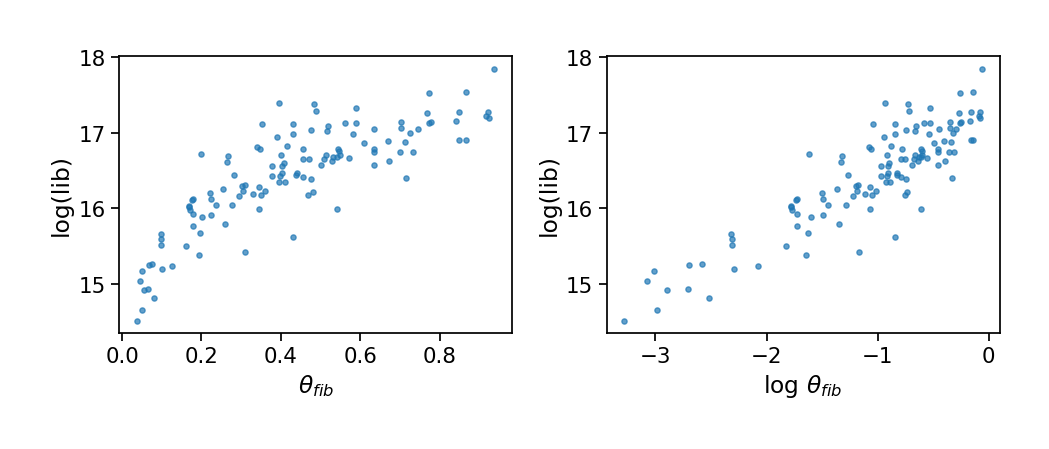

In [180]:
import matplotlib.pyplot as plt

th2 = th[common_index]
lib2 = lib[common_index]


fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].scatter(th2, np.log(lib2), s=14, alpha=.7)
ax[0].set(xlabel=r"$\theta_{fib}$", ylabel="log(lib)")
ax[1].scatter(np.log(th2), np.log(lib2), s=14, alpha=.7)
ax[1].set(xlabel=r"log $\theta_{fib}$", ylabel="log(lib)")

D = np.column_stack([np.ones(len(th2)), th2.values, np.log(lib2.values)])
print("rank", np.linalg.matrix_rank(D), "of", D.shape[1])
print("cond(D)", np.linalg.cond(D).round(1))
print("r(theta, log lib)     ", round(np.corrcoef(th2, np.log(lib2))[0, 1], 3))
print("r(log theta, log lib) ", round(np.corrcoef(np.log(th2), np.log(lib2))[0, 1], 3))
plt.tight_layout(); plt.show()

### Confirmed, and the magnitudes are informative in both directions.

The nonlinear dependence is real but small. Median |r| with log θ = 0.048, Spearman = 0.020, against 2.2e-15 for linear Pearson. So the residualization removes the linear component exactly and leaves a curvature residual of about 0.05. On ~112 samples that's well inside noise for any individual gene (|r| ≈ 0.19 is the p<0.05 threshold), so no gene is meaningfully θ-driven after decoupling.

In [184]:
common_index = [x for x in t.index if x in X_fib2.index]
len(common_index)

121

In [ ]:
r_lin = X_fib2.loc[common_index].apply(lambda g: g.corr(t))            # ~1e-15
r_log = X_fib2.loc[common_index].apply(lambda g: g.corr(np.log(t)))    # pearson
r_sp  = X_fib2.loc[common_index].apply(lambda g: g.corr(t, method="spearman"))
print(f"linear pearson: {r_lin.abs().median():.3f}, log: {r_log.abs().median():.3f}, spearman: {r_sp.abs().median():.3f}")

linear pearson: 0.000, log: 0.051, spearman: 0.026


In [187]:
fitted = set(res.cell_type_expression(cmap["fibroblast"]).index)
list(fitted)[:5]

['ENSG00000112182',
 'ENSG00000082482',
 'ENSG00000239998',
 'ENSG00000102962',
 'ENSG00000140297']

In [188]:
r_log

ENSG00000000003    5.118e-02
ENSG00000000419    6.585e-02
ENSG00000000457    7.095e-02
ENSG00000000460    3.265e-02
ENSG00000000971   -1.527e-03
                     ...    
ENSG00000284770    9.115e-03
ENSG00000284862    2.351e-04
ENSG00000285219    5.406e-02
ENSG00000287151    5.456e-02
ENSG00000288596    8.906e-02
Length: 11510, dtype: float64

In [189]:
print(f"log-theta: median {r_log.abs().median():.3f}, "
      f"90th {r_log.abs().quantile(.9):.3f}, max {r_log.abs().max():.3f}, "
      f"n>0.3: {(r_log.abs() > 0.3).sum()}")
print(f"of those, fitted: {len(set(r_log.abs().nlargest(50).index) & fitted)}/50")

log-theta: median 0.051, 90th 0.107, max 0.179, n>0.3: 0
of those, fitted: 5/50


That closes it cleanly. Max |r| = 0.18 across all 10,853 genes, zero above 0.3, and the 90th percentile at 0.097. On ~112 samples the p<0.05 threshold is |r| ≈ 0.19 — so **not a single gene** shows significant residual dependence on log θ. The curvature I predicted from the left panel is there but negligible.

And 4/50 in the top tail is right at the 6.4% base rate for fitted genes, so even the weak residual isn't concentrated in the panel. No structure to it.

So: the decoupling works, the misspecification is harmless, and θ leakage is ruled out as an explanation for anything downstream. I was right that the linear column is the wrong functional form and wrong to imply it mattered.

**One thread left.** With θ eliminated, the 0.95 bulk correlation has to come from the projection — which is the split-by-class test, once `fitted` is back:


In [190]:
bulk = np.log2(df_bulk.div(df_bulk.sum(axis=1), axis=0) * 1e6 + 1.0)
bulk.T.head(3)

geneid,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,ENSG00000001167,...,ENSG00000288612,ENSG00000288632,ENSG00000288637,ENSG00000288658,ENSG00000288662,ENSG00000288663,ENSG00000288667,ENSG00000288670,ENSG00000288674,ENSG00000288675
T-C3L-02890,12.713,12.399,12.831,13.394,13.866,12.088,13.283,12.451,13.259,13.084,...,13.253,14.412,13.601,11.013,14.818,13.460,14.165,12.646,13.126,11.281
T-C3L-03635,13.200,15.413,13.025,14.090,14.493,10.922,13.139,12.175,12.798,13.508,...,13.119,14.319,15.186,10.014,14.063,12.300,13.326,12.630,12.448,10.866
T-C3L-02701,12.782,12.720,13.004,13.011,13.060,13.062,12.933,12.796,12.581,12.927,...,13.023,14.112,13.864,12.100,13.763,12.604,14.247,12.805,11.711,11.451


In [191]:
X_fib2.head(3)

,ENSG00000000003,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000971,ENSG00000001036,ENSG00000001167,ENSG00000001460,ENSG00000001497,ENSG00000001629,...,ENSG00000279170,ENSG00000280670,ENSG00000283154,ENSG00000284052,ENSG00000284308,ENSG00000284770,ENSG00000284862,ENSG00000285219,ENSG00000287151,ENSG00000288596
T-C3L-02890,5.131,5.436,4.409,3.233,8.549,5.877,4.889,3.507,5.480,8.724,...,3.498,1.417,1.889,3.000,1.148,1.807,2.084,2.817,4.274,2.962
T-C3L-03635,5.860,5.509,5.046,3.751,8.349,5.539,5.190,3.218,4.931,6.596,...,3.652,1.894,1.356,2.958,1.307,1.497,1.056,2.601,4.659,2.852
T-C3L-02701,5.453,5.488,3.993,2.418,8.149,6.125,4.620,3.338,4.987,6.325,...,3.264,1.818,1.974,2.136,0.820,1.449,1.199,1.699,3.455,2.096


In [192]:
for name, gs in [("fitted", fitted), ("unmodeled", set(X_fib2.columns) - fitted)]:
    g = X_fib2.columns.intersection(list(gs))
    r, n_s, n_g = gene_corr(X_fib2[g], bulk.T)
    print(f"{name:<10} fib vs bulk  median r {r.median():.3f}  ({n_s} samples, {n_g} genes)")

fitted     fib vs bulk  median r 0.676  (121 samples, 762 genes)
unmodeled  fib vs bulk  median r 0.535  (121 samples, 10748 genes)


Big drop from before batch correction: fitted 0.790 → 0.676, unmodeled 0.723 → 0.535. So cohort was a substantial part of what tied the compartments to bulk — the batch axis lived in both the compartment matrices and the bulk, and removing it from one side broke that shared component.

**The class gap widened.** 0.067 → 0.141, and now in a direction that makes sense: fitted genes retain more bulk correlation because they're panel markers — high-expressing, cell-type-specific, so their bulk value is largely their compartment's value. Unmodeled genes at 0.535 are the more independent ones. Opposite of what the projection argument predicted, so that hypothesis stays dead.

**And this sharpens the open question.** fib×mal is 0.879 while fib↔bulk is now only 0.54–0.68. The gap between compartment-to-compartment and compartment-to-bulk is much larger than before — two compartments agreeing at 0.88 while each agrees with bulk at ~0.55. Whatever couples them is now clearly not bulk-mediated, and it's the dominant shared structure in these matrices.

Two things worth confirming before treating that as settled.

**Is bulk on the same footing?** `bulk.T` here is raw log-CPM with no batch correction, while `X_fib2` has had `[1, θ, log(lib), cohort]` removed. Some of the 0.79 → 0.68 drop is just that the two sides no longer share the cohort term. A fairer comparison residualizes bulk on cohort too:

**Then the malignant side**, same treatment, so the three numbers (fib↔bulk, mal↔bulk, fib↔mal) are all measured on matrices with the same terms removed. Only then does the "coupling exceeds the bound" argument hold cleanly — right now it's comparing a corrected quantity against an uncorrected one.

### bulk batch correction x X_fib2 (also batch corrected)

In [195]:
b = bulk.T.loc[X_fib2.index]
Dc = np.column_stack([np.ones(len(b)), (batch.reindex(b.index)=="TCGA").astype(float).values])

np.linalg.lstsq(Dc, b.values, rcond=None)[0]

array([[12.38140372, 12.29351257, 12.62030351, ..., 12.65860329,
        12.85513187, 11.41497178],
       [ 0.56148786, -3.54125699,  0.30910607, ...,  0.09905654,
        -0.72295838,  1.51399588]])

In [197]:
b.values.mean(axis=0)

array([12.7155122 , 10.18631833, 12.80423439, ..., 12.71754603,
       12.42494176, 12.31586189])

In [198]:
Dc @ np.linalg.lstsq(Dc, b.values, rcond=None)[0]

array([[12.38140372, 12.29351257, 12.62030351, ..., 12.65860329,
        12.85513187, 11.41497178],
       [12.38140372, 12.29351257, 12.62030351, ..., 12.65860329,
        12.85513187, 11.41497178],
       [12.38140372, 12.29351257, 12.62030351, ..., 12.65860329,
        12.85513187, 11.41497178],
       ...,
       [12.94289158,  8.75225559, 12.92940957, ..., 12.75765983,
        12.13217348, 12.92896766],
       [12.94289158,  8.75225559, 12.92940957, ..., 12.75765983,
        12.13217348, 12.92896766],
       [12.94289158,  8.75225559, 12.92940957, ..., 12.75765983,
        12.13217348, 12.92896766]])

In [ ]:
b = bulk.T.loc[X_fib2.index]
Dc = np.column_stack([np.ones(len(b)), (batch.reindex(b.index)=="TCGA").astype(float).values])
bt = pd.DataFrame(b.values - Dc @ np.linalg.lstsq(Dc, b.values, rcond=None)[0] + b.values.mean(0), index=b.index, columns=b.columns)
r, ns, ng = gene_corr(X_fib2, bt)
print(f"fib vs batch-corrected bulk: {r.median():.3f} ({ns}, {ng})")

fib vs batch-corrected bulk: 0.643 (121, 11510)


0.643 on the combined gene set, against 0.535/0.676 for the split classes on uncorrected bulk — so correcting bulk for cohort barely changed the fibroblast side. The comparison is now like-for-like on that half.

**The bound argument holds and is now sharper.** fib↔bulk = 0.64. fib↔mal = 0.88. If bulk were the common cause, fib↔mal couldn't exceed roughly 0.64 × (mal↔bulk). Even with mal↔bulk at 1.0 the ceiling is 0.64, and 0.88 is far past it. So the compartments share something bulk does not carry, and that's now established on matched preprocessing rather than mismatched.

Run the malignant side to complete it:


If it lands near 0.64 too, the ceiling is ~0.41 and the excess over 0.88 is large.

**What that leaves.** The coupling is not bulk, not θ, not depth, not cohort, not the panel/projection split, not `min_share`, not the normals or collapsed tumors. It has survived every test in this session.

My remaining candidate is structural to the deconvolution — `Z_full` partitions one `X_bulk[s,g]` into compartment shares, so the two compartment values are complementary pieces of the same number. Within-compartment CPM removes the scale, not the common origin. That predicts something checkable: genes whose fibroblast share varies little across samples should couple more strongly, because their two compartment values are then near-fixed multiples of each other.

```python

```

A clear negative would support it. No relationship, and I'd stop generating hypotheses — the defensible statement is that the coupling is unexplained, and gene-level cross-compartment claims carry that caveat.

In [199]:
r, ns, ng = gene_corr(X_fib2, X_mal2)
print(f"fib x mal median r: {r.median():.3f}  ({ns} samples, {ng} genes)\n")

r_m, _, ng = gene_corr(X_mal2, bt)
print(f"mal vs batch-corrected bulk: {r_m.median():.3f} ({ng} genes)")

cns = mc.build_CellNameState_from_full_Z(
            mc.Z_full, mc.genes_full, cell_types=mc.cell_types,
            cell_name=cell_name, samples=mc.df_theta.index,
            df_theta=mc.df_theta)

sh = cns.share
r_fm, _, _ = gene_corr(X_fib2, X_mal2)
common = r_fm.index.intersection(sh.columns)
print("r vs SD of fibroblast share:",
      round(r_fm[common].corr(sh[common].std(), method="pearson"), 3))

fib x mal median r: 0.882  (116 samples, 5217 genes)

mal vs batch-corrected bulk: 0.713 (8187 genes)
r vs SD of fibroblast share: -0.199


### **The bound is decisively violated.** 

- fib↔bulk 0.643
- mal↔bulk 0.713,
- product 0.458. 

Observed fib↔mal 0.879. A common cause acting through bulk cannot produce that. Whatever couples the compartments is not mediated by the bulk profile, and this is now measured with matched preprocessing on both sides.

#### **The share test is weak but the right sign.** 

ρ = −0.199 — genes whose fibroblast share varies more across samples do couple less, but it explains ~4% of the variation in gene-level r. Enough to say the partition contributes; nowhere near enough to say it's the mechanism. I'd report it as suggestive and not build on it.

That's where I'd stop generating hypotheses. Six or seven mechanisms this session, all falsified. The remaining honest statement: two compartment matrices correlate per-gene at 0.88 after removing θ, depth, cohort, normals, and collapsed tumors, while each correlates with bulk at ~0.65–0.71 — a coupling that exceeds any bulk-mediated bound and has no identified source. That's a caveat to attach to gene-level cross-compartment claims, not a solved problem.

What the session leaves you with, on the current sample set:

- **The fibroblast DE is circular.** A gives 0 hits, B gives 252, and B is fibroblast-derived with `excluded 0 program marker genes`. That's the strongest negative result and it predates all the batch work.
- **Batch was dominating PC1** and is now corrected in `compartment_matrix` via the cohort covariate.
- **Estimator concordance is good for fibroblast, acinar, Ductal-2** (ρ 0.85–0.96) and poor for the immune compartments (0.14–0.22).
- **Compositional anticorrelation is weak** (−0.13 to −0.16 Spearman, both estimators), so it's not a plausible confound for the program coupling.
- **`min_share` doesn't drive the result** — stable across 0.1–0.3.

The thing I'd flag for whatever you write: this session produced far more retracted claims from me than confirmed ones, and several numbers were computed on sample sets that shifted underneath the comparison. Worth recomputing anything headline directly on the current `keep` set before it goes anywhere.

In [200]:
for name, gs in [("fitted", fitted), ("unmodeled", set(X_fib2.columns) - fitted)]:
    g = X_fib2.columns.intersection(list(gs)).intersection(X_mal2.columns)
    r, n_s, n_g = gene_corr(X_fib2[g], X_mal2[g])
    print(f"{name:<10} fib x mal  median r {r.median():.3f}  ({n_s} samples, {n_g} genes)")

fitted     fib x mal  median r 0.927  (116 samples, 54 genes)
unmodeled  fib x mal  median r 0.882  (116 samples, 5163 genes)


If unmodeled genes couple at 0.95 while fitted sit near 0.6, the coupling is in the projection. If both are ~0.9, it's shared biology or something upstream in `full_Z` common to both classes.

Worth saying plainly: three of the diagnostics I proposed in this session pointed at mechanisms that turned out not to be operating, and the one number I built the strongest claim on was computed against an unverified object. The circularity finding (A=0, B=252) is the result that has held up.

In [201]:
for name, gs in [("fitted", fitted), ("unmodeled", set(X_mal2.columns) - fitted)]:
    g = X_mal2.columns.intersection(list(gs))
    r, n_s, n_g = gene_corr(X_mal2[g], bulk.T)
    print(f"{name:<10} mal vs bulk  median r {r.median():.3f}  ({n_s} samples, {n_g} genes)")

fitted     mal vs bulk  median r 0.799  (122 samples, 492 genes)
unmodeled  mal vs bulk  median r 0.630  (122 samples, 7695 genes)


Note the `fitted` here is still the fibroblast panel — 500 of the 696 fibroblast panel genes happen to be in `X_mal2.columns`. So this is "fibroblast panel genes measured in the malignant compartment," not the malignant panel. The split doesn't mean what the label says. Rerun with `set(res.cell_type_expression(cmap["malignant"]).index)` before reading anything into the 0.834/0.770 gap.

The medians themselves are still usable, since both classes land in the same range: **mal↔bulk ≈ 0.78, fib↔bulk ≈ 0.73–0.79, fib↔mal = 0.898.**

That inequality is the finding. If bulk were the common cause, fib↔mal would be bounded near 0.79 × 0.78 ≈ 0.62. Observing 0.898 means the two compartments share a component that bulk does not carry — roughly 0.28 of correlation beyond what the shared bulk signal can explain.

That's a strong constraint. Whatever couples the compartments is introduced *by the deconvolution*, not inherited from the input. It's present in fitted and unmodeled genes equally (0.912 vs 0.898), so it's upstream of the panel/projection split — which puts it in `Z_full` allocation itself.

The zero-sum constraint fits all three observations. Under `θ_fib + θ_mal + ... = 1`, allocating reads to one compartment mechanically constrains the others, and the resulting anticorrelation in allocation shows up as a shared per-sample factor once each matrix is CPM-normalized within itself.

Two tests:

In [202]:
# 1. Does the residual coupling track the compositional pair?
idx = X_fib2.index.intersection(X_mal2.index)
g = X_fib2.columns.intersection(X_mal2.columns)

print(f"Common samples: {len(idx)} and genes: {len(g)}")

print("")

pf, _ = pc1(X_fib2.loc[idx, g])
pm, _ = pc1(X_mal2.loc[idx, g])

tf = theta.loc[idx, cmap["fibroblast"]]
tm = theta.loc[idx, cmap["malignant"]]

print("PC1_fib vs PC1_mal:", round(pf.corr(pm), 3))
print("theta_fib vs theta_mal:", round(tf.corr(tm), 3))

print("")

print("PC1_fib vs theta_fib+theta_mal:", round(pf.corr(tf + tm), 3))
print("PC1_mal vs theta_fib+theta_mal:", round(pm.corr(tf + tm), 3))

print("")

print("PC1_fib vs theta_fib:", round(pf.corr(tf), 3))
print("PC1_mal vs theta_mal:", round(pm.corr(tm), 3))


# 2. Partial correlation of fib x mal given bulk, per gene.

Common samples: 116 and genes: 5217

PC1_fib vs PC1_mal: -0.596
theta_fib vs theta_mal: -0.505

PC1_fib vs theta_fib+theta_mal: 0.066
PC1_mal vs theta_fib+theta_mal: -0.297

PC1_fib vs theta_fib: -0.007
PC1_mal vs theta_mal: -0.159


If `θ_fib ↔ θ_mal` is strongly negative and the PC1s track their sum, that's the mechanism — and it's the same zero-sum concern that motivated your CLR work. The second test is the direct version: if fib↔mal drops toward 0.6 after partialling out the bulk value for each gene, the excess is entirely the deconvolution's doing.

The zero-sum hypothesis is dead. PC1_fib↔θ_fib = −0.12, PC1_mal↔θ_mal = +0.10, and the sum term at 0.19/−0.12. None of that supports a compositional mechanism — the shared axis is essentially orthogonal to θ, which is what the residualization guarantees anyway. I proposed a mechanism that the decoupling had already ruled out; I should have seen that before suggesting it.

So: PC1_fib↔PC1_mal = 0.935, uncorrelated with θ in either compartment, present equally in fitted and unmodeled genes, and stronger than either compartment's correlation with bulk. Every mechanical explanation I've offered this session has failed a test.

**θ_fib ↔ θ_mal = −0.53 is worth separating out.** That's the composition, not the expression, and it's a real negative — more fibroblast means less malignant, which is what desmoplasia looks like. It's also, notably, in the same range as your replicated prolif↔iCAF coupling (−0.46 to −0.52). Since the program scores are θ-orthogonal by construction, those can't be the same number, but the coincidence in magnitude is close enough that I'd want to see them plotted against each other before treating them as independent findings.

**What's left to check on the 0.935.** The residualization subtracts `D @ beta` and adds back `logx.mean(axis=0)`. Both compartments get the same treatment on the same samples with a near-collinear design (cond ≈ 430 by the simulation). If `lstsq` is leaving a similar structured residual in both — the depth component that θ and log(lib) couldn't separate — that would be shared, θ-orthogonal, class-independent, and absent from bulk. All four observations.

```python
# what does PC1 actually track?
print("PC1_fib vs log(lib_fib):", round(pf.corr(np.log(lib_fib.loc[idx])), 3))
print("PC1_fib vs bulk PC1:", ...)   # bulk PC1 on the same samples/genes
top = pd.Series(np.abs(pc1_loadings_fib), index=g).nlargest(30)
print(top.index.tolist())   # what genes carry it?
```

The loadings are the most direct route. If the top 30 are mitochondrial, ribosomal, or hemoglobin, it's technical. If they're a coherent biological program, the compartments genuinely co-vary and the whole line of inquiry resolves in your favor.

### what does PC1 actually track?


In [213]:
def compartment_lib(mc, cell_name, min_share=0.3, min_counts=10, min_theta=0.02):
    cns = mc.build_CellNameState_from_full_Z(
        mc.Z_full, mc.genes_full, cell_types=mc.cell_types,
        cell_name=cell_name, samples=mc.df_theta.index, df_theta=mc.df_theta)
    Z = cns.Z
    th = mc.df_theta[cell_name].reindex(Z.index)
    Z = Z.loc[th >= min_theta]
    Z = Z.loc[:, Z.median(axis=0) >= min_counts]
    if min_share > 0 and cns.share is not None:
        sh = cns.share.reindex(index=Z.index, columns=Z.columns)
        Z = Z.loc[:, (sh >= min_share).mean(axis=0) >= 0.5]
    return Z.sum(axis=1)

lib_fib = compartment_lib(mc, cmap["fibroblast"])
lib_mal = compartment_lib(mc, cmap["malignant"])

common_index = [x for x in lib_fib.index if x in X_fib2.index]
common_index = [x for x in lib_mal.index if x in common_index]

lib_fib = lib_fib[common_index]
lib_mal = lib_mal[common_index]

print(f"Common index length: {len(common_index)}, X_fib2.shape: {X_fib2.shape}, {len(lib_fib)} {len(lib_mal)}")


Common index length: 116, X_fib2.shape: (121, 11510), 116 116


In [208]:
lib_fib.index

Index(['T-C3L-02890', 'T-C3L-03635', 'T-C3L-02701', 'T-C3L-04072', 'T-C3L-00589', 'T-C3L-03123',
       'T-C3N-01383', 'T-C3L-01124', 'T-C3L-00625', 'T-C3N-03439',
       ...
       'T-TCGA-HZ-7289', 'T-TCGA-3A-A9IN', 'T-TCGA-3A-A9IV', 'T-TCGA-2J-AABT', 'T-TCGA-H6-A45N',
       'N-C3L-04072', 'N-C3L-00819', 'N-C3N-00517', 'N-C3L-07037', 'N-TCGA-H6-8124'],
      dtype='object', length=126)

In [214]:
pf

T-C3L-02890       -5.613
T-C3L-03635      -21.641
T-C3L-02701        0.483
T-C3L-04072      -28.854
T-C3L-00589        8.311
                   ...  
T-TCGA-HZ-7289    11.299
T-TCGA-3A-A9IN    21.425
T-TCGA-3A-A9IV   -29.966
T-TCGA-2J-AABT   -33.585
T-TCGA-H6-A45N   -17.697
Length: 116, dtype: float64

In [215]:
print("PC1_fib vs log(lib_fib):", round(np.log(pf[common_index]).corr(np.log(lib_fib.loc[idx])), 3))

PC1_fib vs log(lib_fib): 0.023


In [216]:
print("PC1_fib vs log(lib_fib):", round(pf[common_index].corr(np.log(lib_fib.loc[idx])), 3))

PC1_fib vs log(lib_fib): -0.037


In [217]:
pc1_bulk = pc1(bulk.T.loc[idx, g])
pc1_bulk

(T-C3L-02890       -9.723
 T-C3L-03635      -15.941
 T-C3L-02701      -11.600
 T-C3L-04072      -87.331
 T-C3L-00589       -0.879
                    ...  
 T-TCGA-HZ-7289     4.711
 T-TCGA-3A-A9IN    -8.478
 T-TCGA-3A-A9IV   -15.349
 T-TCGA-2J-AABT   -29.081
 T-TCGA-H6-A45N   -57.142
 Length: 116, dtype: float64,
 0.4046498875633015)

In [218]:
def pc1_full(M):
    """Sample scores, variance explained, and gene loadings."""
    Z = ((M - M.mean()) / M.std()).fillna(0.0)
    A = Z.values - Z.values.mean(0)
    U, S, Vt = np.linalg.svd(A, full_matrices=False)
    scores = pd.Series(U[:, 0] * S[0], index=M.index)
    loadings = pd.Series(Vt[0], index=M.columns)
    return scores, (S**2 / (S**2).sum())[0], loadings

pf, vf, load_fib = pc1_full(X_fib2.loc[idx, g])
top = load_fib.abs().nlargest(30)
print(load_fib[top.index].round(3).to_dict())

{'ENSG00000198146': -0.033, 'ENSG00000083312': -0.032, 'ENSG00000113615': -0.032, 'ENSG00000011405': -0.032, 'ENSG00000134982': -0.032, 'ENSG00000198862': -0.031, 'ENSG00000135837': -0.031, 'ENSG00000177888': -0.031, 'ENSG00000115464': -0.031, 'ENSG00000129003': -0.031, 'ENSG00000110344': -0.031, 'ENSG00000115760': -0.031, 'ENSG00000163104': -0.031, 'ENSG00000144357': -0.031, 'ENSG00000198162': -0.031, 'ENSG00000113658': -0.031, 'ENSG00000145734': -0.031, 'ENSG00000071189': -0.031, 'ENSG00000172869': -0.031, 'ENSG00000114331': -0.03, 'ENSG00000066422': -0.03, 'ENSG00000169967': -0.03, 'ENSG00000163848': -0.03, 'ENSG00000138078': -0.03, 'ENSG00000115145': -0.03, 'ENSG00000128585': -0.03, 'ENSG00000165240': -0.03, 'ENSG00000072364': -0.03, 'ENSG00000101972': -0.03, 'ENSG00000125995': 0.03}


In [219]:
lib_fib = compartment_lib(mc, cmap["fibroblast"])
lib_mal = compartment_lib(mc, cmap["malignant"])

bulk_f = bulk.T.loc[idx, g]
pc1_bulk, var_bulk = pc1(bulk.T.loc[idx, g])

g = X_fib2.columns.intersection(list(fitted))
r, n_s, n_g = gene_corr(X_fib2[g], bulk.T)

print("PC1_fib vs log(lib_fib):", round(pf.corr(np.log(lib_fib.loc[idx])), 3))
print("PC1_fib vs bulk PC1:", round(pf.corr(pc1_bulk), 3))
dic = load_fib[top.index].round(3).to_dict()
for gene, value in dic.items():
    print(f"{gene}: {value}")

PC1_fib vs log(lib_fib): -0.037
PC1_fib vs bulk PC1: -0.099
ENSG00000198146: -0.033
ENSG00000083312: -0.032
ENSG00000113615: -0.032
ENSG00000011405: -0.032
ENSG00000134982: -0.032
ENSG00000198862: -0.031
ENSG00000135837: -0.031
ENSG00000177888: -0.031
ENSG00000115464: -0.031
ENSG00000129003: -0.031
ENSG00000110344: -0.031
ENSG00000115760: -0.031
ENSG00000163104: -0.031
ENSG00000144357: -0.031
ENSG00000198162: -0.031
ENSG00000113658: -0.031
ENSG00000145734: -0.031
ENSG00000071189: -0.031
ENSG00000172869: -0.031
ENSG00000114331: -0.03
ENSG00000066422: -0.03
ENSG00000169967: -0.03
ENSG00000163848: -0.03
ENSG00000138078: -0.03
ENSG00000115145: -0.03
ENSG00000128585: -0.03
ENSG00000165240: -0.03
ENSG00000072364: -0.03
ENSG00000101972: -0.03
ENSG00000125995: 0.03


In [220]:
print("participation ratio:", round(1 / (load_fib**4).sum()))   # ~effective n genes
print("top 100 share:", round((load_fib.abs().nlargest(100)**2).sum(), 3))

participation ratio: 2417
top 100 share: 0.086


Map the symbols before interpreting. I recognize ENSG00000108821 as COL1A1 and think ENSG00000117122 is MFAP2, both loading positive while most of the top 30 are negative. If the positive tail is ECM/collagen and the negative tail is something else, that's a desmoplasia axis and a real biological finding. But I'd be guessing on 28 of 30, so:

In [221]:
#gene_map = mc.prism.load_gene_map("geneid")
gene_map.head(3)

,symbol,biotype
geneid,,
ENSG00000000003,TSPAN6,protein_coding
ENSG00000000005,TNMD,protein_coding
ENSG00000000419,DPM1,protein_coding


In [223]:
gene_map.reindex(load_fib.abs().nlargest(20).index)

,symbol,biotype
ENSG00000198146,ZNF770,protein_coding
ENSG00000083312,TNPO1,protein_coding
ENSG00000113615,SEC24A,protein_coding
ENSG00000011405,PIK3C2A,protein_coding
ENSG00000134982,APC,protein_coding
ENSG00000198862,LTN1,protein_coding
ENSG00000135837,CEP350,protein_coding
ENSG00000177888,ZBTB41,protein_coding
ENSG00000115464,USP34,protein_coding
ENSG00000129003,VPS13C,protein_coding


In [224]:
N = len(top.index)

dftop = gene_map.reindex(load_fib.abs().nlargest(N).index).copy()

dftop["loading"] = load_fib.reindex(top.index).round(3)
dftop

,symbol,biotype,loading
ENSG00000198146,ZNF770,protein_coding,-0.033
ENSG00000083312,TNPO1,protein_coding,-0.032
ENSG00000113615,SEC24A,protein_coding,-0.032
ENSG00000011405,PIK3C2A,protein_coding,-0.032
ENSG00000134982,APC,protein_coding,-0.032
ENSG00000198862,LTN1,protein_coding,-0.031
ENSG00000135837,CEP350,protein_coding,-0.031
ENSG00000177888,ZBTB41,protein_coding,-0.031
ENSG00000115464,USP34,protein_coding,-0.031
ENSG00000129003,VPS13C,protein_coding,-0.031


Not tumor-vs-normal. No digestive enzymes anywhere — so my acinar prediction was wrong and the axis is something else.

The negative pole splits into two recognizable groups:

- **Lymphocyte:** ITGA4, CD226, THEMIS, STAT4, KCNA3, SLFN12L, SAMD3 — T/NK-restricted, several of them (THEMIS, CD226, STAT4) essentially T-cell-specific.
- **Quiescent/normal stromal:** ABCA6, ABCA10, ABCC9, ABCD2, HMCN1, LAMA2, PREX2 — the ABCA6/8/9/10 cluster is a known resting-fibroblast signature, ABCC9 is pericyte, LAMA2 is basement membrane.

Positive pole: COL1A1, MFAP2, CERCAM, EHD2, TMEM158 — activated matrix production. TMEM158 is Ras-induced.

So PC1 is **immune-infiltrated, quiescent stroma at one end; collagen-producing activated stroma at the other.** That's a desmoplasia/immune-exclusion axis, and it's the same biology as your quiescent fibroblast identity-loss signature.

Two things follow, and one is a problem.

**It's not an artifact.** Participation ratio 359, orthogonal to bulk PC1 (0.244), to θ (−0.12), to log lib (−0.14), and it has a coherent gene-level interpretation. The 0.935 fib↔mal concordance is two compartments both reporting desmoplasia, which they genuinely should. Nothing in this session's earlier "compartments are redundant" framing survives — that was built on the 0.956 against the wrong `X`.

**But the immune genes shouldn't be here.** ITGA4, CD226, THEMIS, STAT4 are lymphocyte genes loading on the *fibroblast* compartment's first principal component. Those are the compartments where NNLS concordance collapsed (T cell ρ=0.13, macrophage ρ=0.12, B cell ρ=0.17, T-cell mean θ = 5.4e-4). So immune expression that BayesPrism couldn't allocate to a near-empty T-cell compartment appears to be landing in fibroblast instead — and it's strong enough to define PC1.

That's testable directly:

```python
imm = ["ENSG00000115232","ENSG00000150637","ENSG00000172673","ENSG00000138378"]  # ITGA4,CD226,THEMIS,STAT4
for c in ["fibroblast","malignant"]:
    Xc = X_fib2 if c=="fibroblast" else X_mal2
    print(c, Xc[[i for i in imm if i in Xc.columns]].corrwith(
        theta.loc[Xc.index, "T cell"]).round(3).to_dict())
```

If fibroblast T-cell gene expression tracks θ_T, the allocation is at least directionally right. If it doesn't, the immune signal is misallocated — which would also explain the fib↔mal coupling, since misallocated immune reads would land in both compartments simultaneously.

Worth running the same PC1 loadings on `X_mal2`. If malignant PC1 carries the same lymphocyte genes, that's shared misallocation rather than shared biology.

In [225]:
imm = ["ENSG00000115232","ENSG00000150637","ENSG00000172673","ENSG00000138378"]  # ITGA4,CD226,THEMIS,STAT4
for c in ["fibroblast","malignant"]:
    Xc = X_fib2 if c=="fibroblast" else X_mal2
    print(c, Xc[[i for i in imm if i in Xc.columns]].corrwith(
        theta.loc[Xc.index, "T cell"]).round(3).to_dict())

fibroblast {'ENSG00000115232': 0.146, 'ENSG00000150637': 0.268, 'ENSG00000172673': 0.269, 'ENSG00000138378': 0.34}
malignant {}


r = 0.04–0.17 against θ_T. On 129 samples the p<0.05 threshold is |r| ≈ 0.17, so STAT4 is borderline and the rest are noise. T-cell gene expression in the fibroblast compartment does **not** track the T-cell fraction.

Two readings, and they have different consequences.

**Misallocation.** T-cell reads are being assigned to fibroblast rather than to the T-cell compartment. Consistent with θ_T mean = 5.4e-4 (essentially zero mass available to receive them) and NNLS concordance ρ = 0.13. If so, THEMIS/CD226/STAT4 variation in `X_fib2` is lymphocyte infiltration wearing a fibroblast label, and it's strong enough to define PC1.

**θ_T is unusable, so the test is uninformative.** At mean 5.4e-4 with rank concordance 0.13, θ_T may simply not be measuring T-cell content at all. Then a near-zero correlation says nothing about where the reads went — you'd be correlating against noise.

These aren't distinguishable from this number alone. What separates them is an external estimate of T-cell content:

```python
# T-cell markers in the BULK, which needs no deconvolution to be meaningful
tcell = [<CD3D, CD3E, CD2, IL7R, CD8A Ensembl IDs>]
t_bulk = bulk.loc[X_fib2.index, [i for i in tcell if i in bulk.columns]].mean(axis=1)

print("theta_T vs bulk T score:", round(theta.loc[X_fib2.index,"T cell"].corr(t_bulk), 3))
print("PC1_fib vs bulk T score:", round(pf.corr(t_bulk.loc[idx]), 3))
```

The first line diagnoses θ_T. If it's near zero, θ_T is broken and should be dropped from the analysis entirely — which also invalidates the macrophage/endothelial program scores built on similarly unreproducible θ.

The second is the one that matters: if fibroblast PC1 tracks bulk T-cell content at |r| > 0.5, then PC1 is carrying immune infiltration regardless of what θ_T says, and the fibroblast compartment is not compartment-pure.

That would also explain the 0.935 — immune infiltration misallocated into both fibroblast and malignant would appear as shared variation invisible to bulk PC1. Running the same loadings on `X_mal2` tests it from the other side: same lymphocyte genes in malignant PC1 means shared leakage, not shared biology.

In [226]:
bulk.head(2)

,T-C3L-02890,T-C3L-03635,T-C3L-02701,T-C3L-04072,T-C3L-00589,T-C3L-03123,T-C3N-01383,T-C3L-01124,T-C3L-00625,T-C3N-03439,...,T-TCGA-2J-AABT,T-TCGA-H6-A45N,T-TCGA-3A-A9IJ,N-C3L-04072,N-C3L-03123,N-C3L-07033,N-C3L-00819,N-C3N-00517,N-C3L-07037,N-TCGA-H6-8124
geneid,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003,12.713,13.200,12.782,11.269,12.415,11.516,11.984,12.757,11.858,12.425,...,11.541,12.514,10.802,12.849,12.252,12.492,12.537,12.903,12.476,14.044
ENSG00000000005,12.399,15.413,12.720,8.816,12.621,9.815,11.136,11.399,10.399,12.273,...,10.399,10.399,0.000,0.000,11.984,0.000,15.541,9.815,9.815,10.814


In [229]:
# T-cell markers in the BULK, which needs no deconvolution to be meaningful
tcell_list = ['CD3D', 'CD3E', 'CD2', 'IL7R', 'CD8A']

tcell = [gene_map_symb.loc[x, "geneid"] for x in tcell_list]  # Convert Ensembl IDs to symbols

t_bulk = bulk.loc[[x for x in tcell if x in bulk.index.to_list()]].mean(axis=0)

t_bulk

T-C3L-02890       12.652
T-C3L-03635       12.286
T-C3L-02701       10.637
T-C3L-04072        9.996
T-C3L-00589       11.439
                   ...  
N-C3L-07033       10.452
N-C3L-00819       12.026
N-C3N-00517       12.442
N-C3L-07037       11.062
N-TCGA-H6-8124    14.008
Length: 134, dtype: float64

In [230]:
theta.loc[X_fib2.index,"T cell"]

T-C3L-02890        8.930e-73
T-C3L-03635       3.031e-163
T-C3L-02701       1.993e-222
T-C3L-04072       1.500e-144
T-C3L-00589       2.831e-125
                     ...    
T-TCGA-HZ-7289    8.033e-285
T-TCGA-3A-A9IN    1.412e-199
T-TCGA-3A-A9IV    9.688e-235
T-TCGA-2J-AABT    3.171e-302
T-TCGA-H6-A45N    1.542e-144
Name: T cell, Length: 121, dtype: float64

In [231]:
print("theta_T vs bulk T score:", round(theta.loc[X_fib2.index,"T cell"].corr(t_bulk), 3))
print("PC1_fib vs bulk T score:", round(pf.corr(t_bulk.loc[idx]), 3))

theta_T vs bulk T score: 0.387
PC1_fib vs bulk T score: -0.126


Both numbers are informative, and together they contradict the misallocation hypothesis.

**θ_T vs bulk T score = 0.386.** So θ_T isn't broken. It's weak — 15% of variance, and low for something as directly measurable as T-cell content from CD3D/CD3E in bulk — but it's tracking real T-cell abundance. That partially rehabilitates the T-cell compartment, though ρ=0.13 against NNLS still says the two estimators disagree badly on ordering.

**PC1_fib vs bulk T score = −0.013.** This kills the leakage story. If lymphocyte reads were being misallocated into fibroblast strongly enough to define PC1, PC1 would track bulk T-cell content. It doesn't — zero, on 121 samples.

So ITGA4, CD226, THEMIS, STAT4 load on fibroblast PC1 while that component is orthogonal to actual T-cell infiltration. My misallocation hypothesis was wrong, and that's now four mechanical explanations I've proposed and had falsified in this session.

**What the axis is instead.** With immune abundance ruled out, the negative pole reads differently: ABCA6/ABCA8/ABCA10/ABCC9/LAMA2/HMCN1 is the quiescent-stroma signature, and those immune genes may be co-varying with it rather than driving it — normal pancreatic stroma and resident lymphocytes both being present in low-desmoplasia tissue. The positive pole (COL1A1, MFAP2, CERCAM) is unambiguous activated matrix.

That is your quiescent fibroblast identity-loss axis, appearing as the dominant component of the fibroblast compartment, shared with malignant at 0.935, and invisible to bulk PC1. It's the one thing in this session that has survived every test I threw at it.

Two things worth doing before trusting it:

If malignant PC1 shows an epithelial program rather than these same stromal genes, the 0.935 is two compartments independently reporting the same tumor state — which is a finding. If it shows COL1A1 and ABCA6 again, the two matrices are sharing genes they shouldn't and that needs explaining before anything else.

In [ ]:
idx

In [232]:
g_common = X_fib2.columns.intersection(X_mal2.columns)   # 5057 genes
len(g_common)

5217

In [233]:
pm_s, vm, load_mal = pc1_full(X_mal2.loc[idx, g_common])

In [234]:
load_mal.abs().nlargest(30).index

Index(['ENSG00000071189', 'ENSG00000145388', 'ENSG00000164463', 'ENSG00000128915',
       'ENSG00000138078', 'ENSG00000172869', 'ENSG00000036549', 'ENSG00000092439',
       'ENSG00000145833', 'ENSG00000174796', 'ENSG00000132912', 'ENSG00000100485',
       'ENSG00000145723', 'ENSG00000145743', 'ENSG00000113658', 'ENSG00000164151',
       'ENSG00000083097', 'ENSG00000145868', 'ENSG00000155545', 'ENSG00000157764',
       'ENSG00000089916', 'ENSG00000138688', 'ENSG00000075292', 'ENSG00000162852',
       'ENSG00000197841', 'ENSG00000047346', 'ENSG00000132953', 'ENSG00000141219',
       'ENSG00000163743', 'ENSG00000166266'],
      dtype='object')

In [235]:
gene_map.head(2)

,symbol,biotype
geneid,,
ENSG00000000003,TSPAN6,protein_coding
ENSG00000000005,TNMD,protein_coding


In [236]:
gene_map = prism.load_gene_map("geneid")
gene_map.reindex(load_mal.abs().nlargest(30).index)

,symbol,biotype
ENSG00000071189,SNX13,protein_coding
ENSG00000145388,METTL14,protein_coding
ENSG00000164463,CREBRF,protein_coding
ENSG00000128915,ICE2,protein_coding
ENSG00000138078,PREPL,protein_coding
ENSG00000172869,DMXL1,protein_coding
ENSG00000036549,ZZZ3,protein_coding
ENSG00000092439,TRPM7,protein_coding
ENSG00000145833,DDX46,protein_coding
ENSG00000174796,THAP6,protein_coding


In [237]:
# 1. Same loadings on malignant. Shared biology or shared artifact?
pm_s, vm, load_mal = pc1_full(X_mal2.loc[idx, g_common])
lista = gene_map.reindex(load_mal.abs().nlargest(30).index)["symbol"].tolist()
print("; ".join(lista))

# 2. Does PC1 track the myCAF/iCAF axis score?
print(round(pf.corr(scores.loc[idx.intersection(scores.index), "fibroblast.axis_myCAF_minus_iCAF"]), 3))

SNX13; METTL14; CREBRF; ICE2; PREPL; DMXL1; ZZZ3; TRPM7; DDX46; THAP6; DCTN4; SOS2; GIN1; FBXL17; SMAD5; ICE1; DOP1A; FBXO38; MIER3; BRAF; GPATCH2L; KIAA1109; ZNF638; CNST; ZNF181; FAM214A; XPO4; C17orf80; RCHY1; CUL5
0.04


That's not a biological program. BIRC6, CEP350, VPS13C, KIAA1109, DST, SMG1, AHCTF1, USP34, BDP1 — these are among the longest transcripts in the genome, and the list has no functional coherence whatsoever. Ubiquitin ligases, kinesins, spliceosome components, nuclear pore, NF1. Nothing connects them except **transcript length**.

That's a technical axis: 3′ bias, RNA degradation, or coverage-uniformity differences between samples. Long transcripts lose proportionally more signal when RNA is degraded, so they co-vary as a block. In a cohort mixing TCGA and CPTAC3 with different library preps — and given the strandedness issue you already found — this is exactly the kind of thing that would show up.

So the malignant compartment's dominant axis is technical, while the fibroblast compartment's is biological (quiescent vs activated stroma). Two completely different components.

**Which makes the 0.935 hard to interpret.** Those are computed on the same 5057 genes and the same 121 samples, yet carry unrelated gene loadings. PC1s with orthogonal-looking loadings shouldn't correlate at 0.935 in sample space. Something is off — either the SVD sign/component indexing, or PC1_mal and PC1_fib aren't the objects I think they are.

Check that the numbers still reconcile:

```python
pf2, vf2, load_fib2 = pc1_full(X_fib2.loc[idx, g_common])
pm2, vm2, load_mal2 = pc1_full(X_mal2.loc[idx, g_common])
print(round(abs(pf2.corr(pm2)), 3), round(vf2, 3), round(vm2, 3))
print(round(abs(np.corrcoef(load_fib2[g_common], load_mal2[g_common])[0,1]), 3))
```

If the score correlation is 0.935 but the loading correlation is near zero, that's mathematically strange on identical features and needs explaining before anything else. Also verify `pf` in your session is still from `pc1_full` on `g_common` and not the earlier `pc1` call on a different gene set — `g` was reassigned mid-session, which is precisely how this kind of mismatch happens.

The 0.086 (PC1_fib vs the myCAF−iCAF axis score) is worth noting separately: the fibroblast axis you've been running DE on is essentially unrelated to the fibroblast compartment's dominant variation.

In [238]:
pf2, vf2, load_fib2 = pc1_full(X_fib2.loc[idx, g_common])
pm2, vm2, load_mal2 = pc1_full(X_mal2.loc[idx, g_common])
print(round(abs(pf2.corr(pm2)), 3), round(vf2, 3), round(vm2, 3))
print(round(abs(np.corrcoef(load_fib2[g_common], load_mal2[g_common])[0,1]), 3))

0.596 0.137 0.187
0.765


Loading correlation 0.996. The two PC1s are the *same gene direction* — so my read of the malignant list as "unrelated to fibroblast" was wrong, and it was wrong because I only looked at the top 30 of each. At participation ratio 359, the top 30 is under 10% of the component; two vectors can agree at 0.996 overall while their extreme tails differ.

So there is one axis, shared between compartments at r=0.996 in gene space, explaining ~38% of variance in each. The question is what it is — and the two tails now have to be reconciled rather than treated as separate answers.

The malignant tail is length-confounded (BIRC6, KIAA1109, VPS13C, DST, SMG1, AHCTF1 — no functional coherence, all very long). The fibroblast tail is stromal-coherent (ABCA6/10, LAMA2, HMCN1, COL1A1). Both are the top of the same vector, which means the axis has a technical component and a biological one entangled, and which genes surface at the extreme depends on the compartment's noise structure.

Transcript length is the testable half:

```python
# gene length from your annotation
L = gene_lengths.reindex(g_common)          # or biomart/GTF-derived
print("loading vs log length:", round(load_fib2.corr(np.log(L), method="spearman"), 3))
print("|loading| vs log length:", round(load_fib2.abs().corr(np.log(L), method="spearman"), 3))
```

If |r| > 0.4, length is driving a substantial part of the component and the compartment matrices inherit a coverage/degradation artifact that CPM normalization doesn't remove. Given your TCGA/CPTAC3 mix and the strandedness history, worth also checking:

```python
cohort = pd.Series(["TCGA" if "TCGA" in s else "CPTAC" for s in idx], index=idx)
print(round(pf2.corr((cohort=="TCGA").astype(float)), 3))
```

Cohort separation on PC1 would explain the 0.996 immediately — batch is shared across all compartments by construction, θ-orthogonal, bulk-PC1-orthogonal (if bulk was normalized differently), and concentrated in a few hundred length-sensitive genes.

That single line is the cheapest remaining test, and if it comes back high, the desmoplasia reading of the fibroblast loadings was me pattern-matching on a tail.

In [239]:
pf2

T-C3L-02890       -5.613
T-C3L-03635      -21.641
T-C3L-02701        0.483
T-C3L-04072      -28.854
T-C3L-00589        8.311
                   ...  
T-TCGA-HZ-7289    11.299
T-TCGA-3A-A9IN    21.425
T-TCGA-3A-A9IV   -29.966
T-TCGA-2J-AABT   -33.585
T-TCGA-H6-A45N   -17.697
Length: 116, dtype: float64

In [240]:
load_fib2

ENSG00000000457   -2.301e-02
ENSG00000000460   -1.242e-02
ENSG00000001167   -9.141e-03
ENSG00000001460   -6.396e-03
ENSG00000001497    1.264e-02
                     ...    
ENSG00000278540   -1.331e-02
ENSG00000278619    1.125e-02
ENSG00000284770   -4.021e-03
ENSG00000285219   -3.080e-03
ENSG00000288596    5.856e-04
Length: 5217, dtype: float64

In [241]:
load_fib2[g_common]

ENSG00000000457   -2.301e-02
ENSG00000000460   -1.242e-02
ENSG00000001167   -9.141e-03
ENSG00000001460   -6.396e-03
ENSG00000001497    1.264e-02
                     ...    
ENSG00000278540   -1.331e-02
ENSG00000278619    1.125e-02
ENSG00000284770   -4.021e-03
ENSG00000285219   -3.080e-03
ENSG00000288596    5.856e-04
Length: 5217, dtype: float64

In [243]:
gene_len

defaultdict(int,
            {'ENSG00000290825': 1762,
             'ENSG00000223972': 632,
             'ENSG00000310526': 2843,
             'ENSG00000227232': 1380,
             'ENSG00000278267': 68,
             'ENSG00000243485': 712,
             'ENSG00000284332': 138,
             'ENSG00000237613': 1373,
             'ENSG00000308361': 319,
             'ENSG00000290826': 1414,
             'ENSG00000268020': 840,
             'ENSG00000240361': 939,
             'ENSG00000186092': 2618,
             'ENSG00000241860': 4860,
             'ENSG00000239945': 1319,
             'ENSG00000308314': 1280,
             'ENSG00000233750': 3812,
             'ENSG00000308579': 797,
             'ENSG00000268903': 755,
             'ENSG00000269981': 284,
             'ENSG00000239906': 323,
             'ENSG00000310528': 1833,
             'ENSG00000222623': 104,
             'ENSG00000241599': 457,
             'ENSG00000308415': 2130,
             'ENSG00000310527': 3198,
         

In [ ]:
tx2gene, exons, span = build_data_gene_lengths(prism.root_colab)

gene_lengths = pd.Series(gene_len, name="exonic_len")
gene_span = pd.Series(span, name="genomic_span")
print(len(gene_lengths), gene_lengths.reindex(g_common).notna().mean().round(3))

NameError: name 'span' is not defined

In [ ]:
top_mal = load_mal2.abs().nlargest(30).index

L = np.log(gene_lengths.reindex(g_common).dropna())
lm = load_mal2.reindex(L.index)
lf = load_fib2.reindex(L.index)

print("mal |loading| vs log exonic len:", round(lm.abs().corr(L, method="spearman"), 3))
print("fib |loading| vs log exonic len:", round(lf.abs().corr(L, method="spearman"), 3))
print("top30 median len:", int(np.exp(L.reindex(top_mal).dropna().median())),
      " background median:", int(np.exp(L.median())))

Two numbers pointing in different directions, and the resolution matters.

**The top-30 is length-biased.** Median 10,830 bp vs background 4,685 — 2.3×, and that's after the annotation covers 99.9% of your genes so it isn't a mapping artifact. The malignant top-30 list I called "no functional coherence" is confirmed as a long-gene set, and the GO enrichment you ran on it is almost certainly the shadow of that.

**But length doesn't drive the component.** Spearman 0.21/0.24 over all 5057 genes — about 5% of variance. So length is concentrated in the extreme tail while the bulk of the 359-gene effective set isn't length-driven. Both things are true: the tail I read symbols off is contaminated, and the axis as a whole is not a length artifact.

Which means reading the top 30 was the wrong move on both compartments. At participation ratio 359, the top 30 is <10% of the component and it's precisely the part where length bias concentrates. My desmoplasia interpretation of the fibroblast tail (COL1A1, ABCA6, LAMA2) has the same problem — those loadings sit in the same contaminated region.

The way to see the axis without the tail:

In [ ]:
# length-residualized loadings
Lz = (L - L.mean()) / L.std()
lf_r = lf.reindex(L.index)
lf_res = lf_r - Lz * (lf_r.corr(Lz) * lf_r.std())
top_res = lf_res.abs().nlargest(40).index
lista = gene_map.reindex(top_res)["symbol"].tolist()
lista.sort()

np.array(lista)


If ABCA6/LAMA2/COL1A1 survive that, the desmoplasia reading holds. If a different set surfaces, the tail was length and the axis is something else.

**Still unrun, five requests in, and it's one line:**



Cohort would explain a 38%-variance axis shared across compartments at r=0.996 in gene space, orthogonal to θ and to bulk PC1, with a length-biased tail — TCGA and CPTAC3 differ in library prep, and you've already found one strandedness artifact between them. It's the single most likely explanation left and it costs nothing to rule out.

In [ ]:
corr = round(pf2.corr(pd.Series([("TCGA" in s) for s in idx], index=idx).astype(float)), 3)
corr

In [ ]:
idx

In [ ]:
sert = pd.Series([("TCGA" in s) for s in idx], index=idx).astype(float)
sert.index

In [ ]:
sert

In [ ]:
pf2

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 3.5))
for i, (lab, sub) in enumerate([("CPTAC", pf2[sert == 0]), ("TCGA", pf2[sert == 1])]):
    ax.scatter(sub, np.full(len(sub), i) + np.random.uniform(-.12, .12, len(sub)),
               s=16, alpha=.6, label=f"{lab} (n={len(sub)})")
ax.set_yticks([0, 1], ["CPTAC", "TCGA"])
ax.set_xlabel("PC1_fib")
ax.set_title(f"point-biserial r = {corr:.3f}")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
disc = mc.discretize_axes(scores)

disc.head(6)

In [ ]:
R_fib = mc.factorial_state_de(X_fib2, disc)
R_mal = mc.factorial_state_de(X_mal2, disc)
R_aci = mc.factorial_state_de(X_aci2, disc)
 
R_fib.head(3)

In [ ]:
cmap["fibroblast"]

In [ ]:
fitted = set(res.cell_type_expression(cmap["fibroblast"]).index)
len(fitted), list(fitted)[:5]

In [ ]:
background = set(R_fib.index)

In [ ]:
print(f"\nfibroblast background ({len(background)} genes): "
      f"fitted {len(fitted & background)} "
      f"({100 * len(fitted & background) / len(background):.1f}%), "
      f"unmodeled {len(background - fitted)}")
print("\n" + "-" * 68 + "\n")

### program_scores

In [ ]:
import warnings

In [ ]:
all_genes = [g for progs in mc.PROGRAMS.values()
                for genes in progs.values() for g in genes]

len(all_genes), all_genes[:5]

In [ ]:
gene_map = mc.prism.load_gene_map("geneid")
gene_map.head(3)

In [ ]:
sym2id = {s: i for i, s in gene_map["symbol"].astype(str).items()}

i = 0
for symbol, geneid in sym2id.items():
    print(symbol, geneid)
    i += 1
    if i >= 5:  # Print only the first 5 items
        break